Apple Silicon GPU detected (MPS)
Using mps device


/opt/anaconda3/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


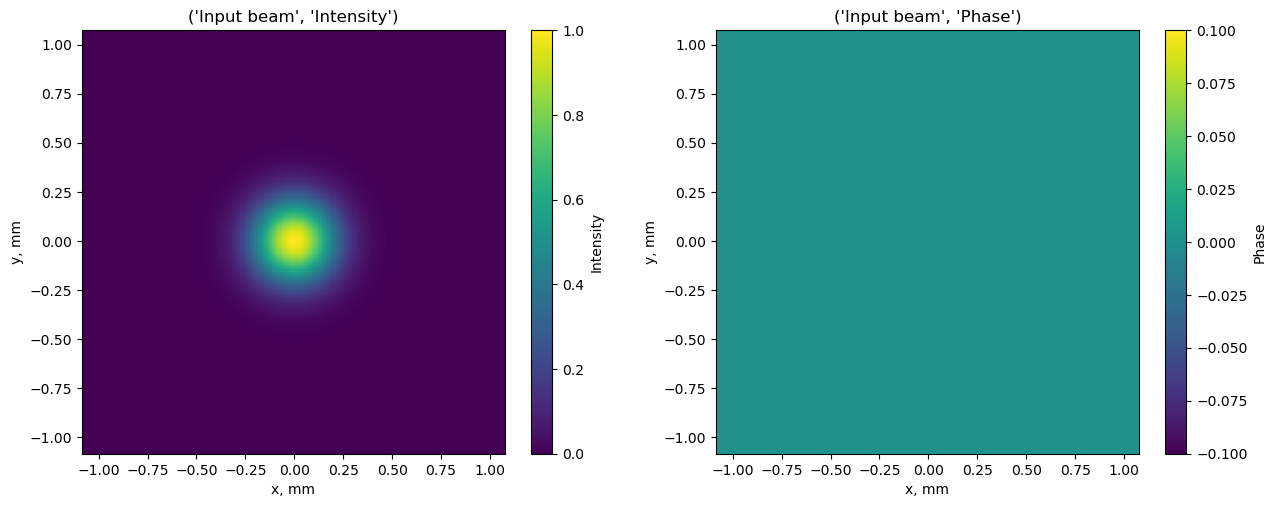

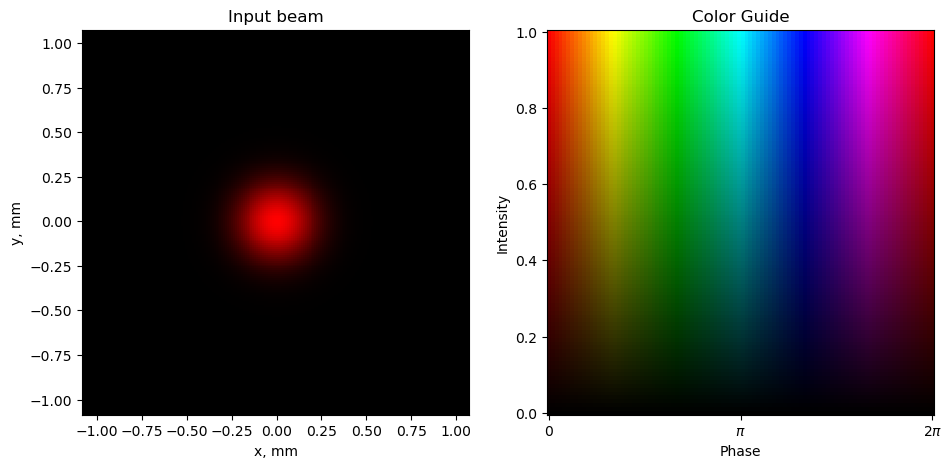

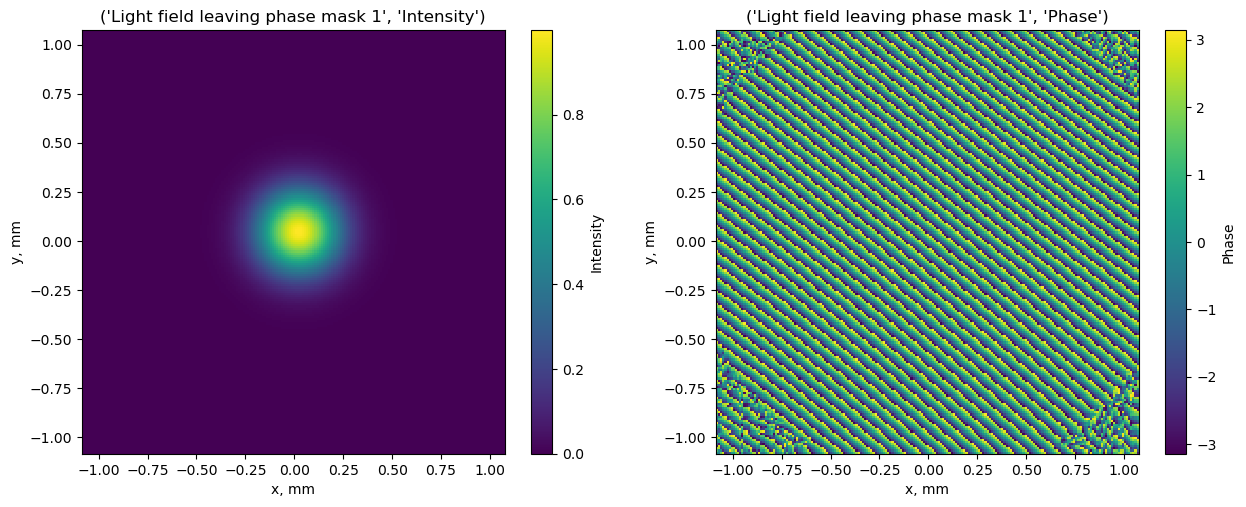

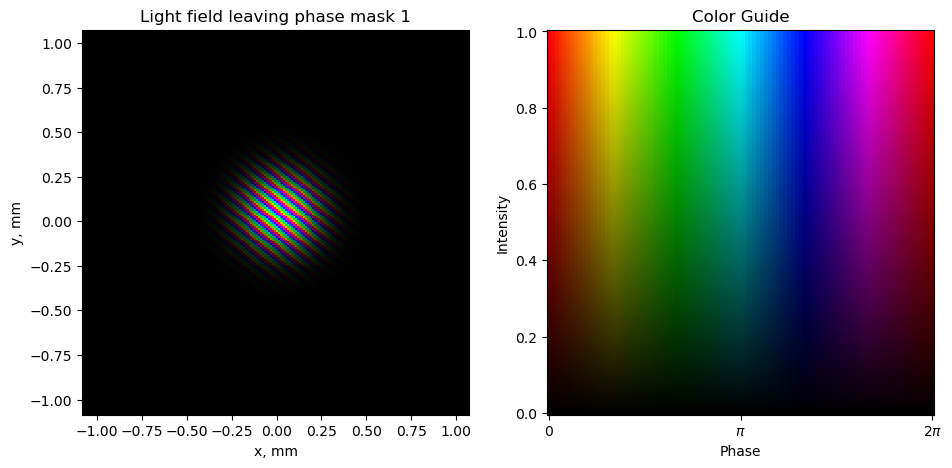

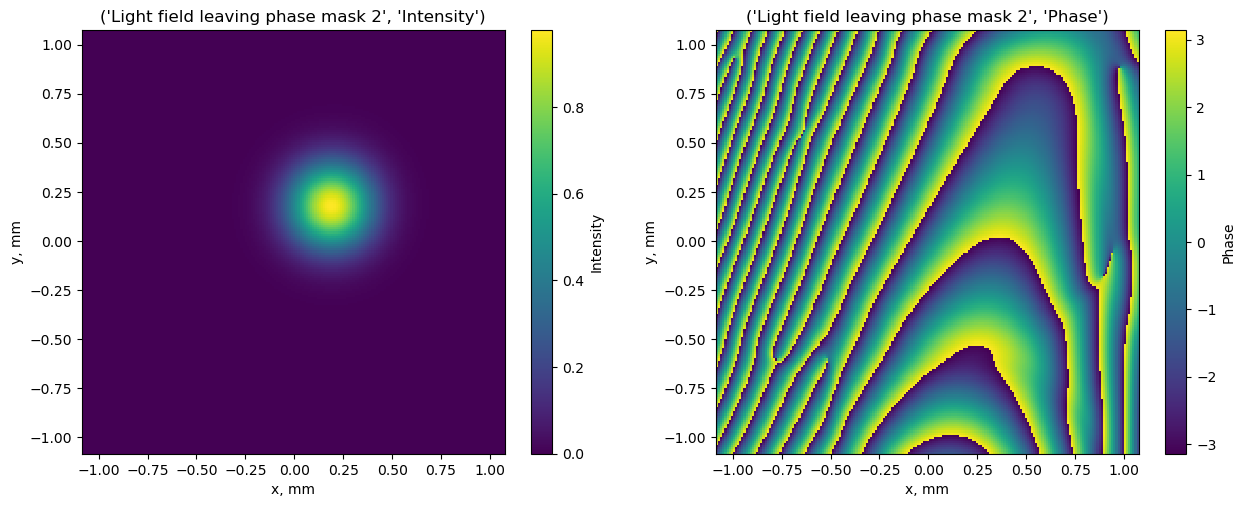

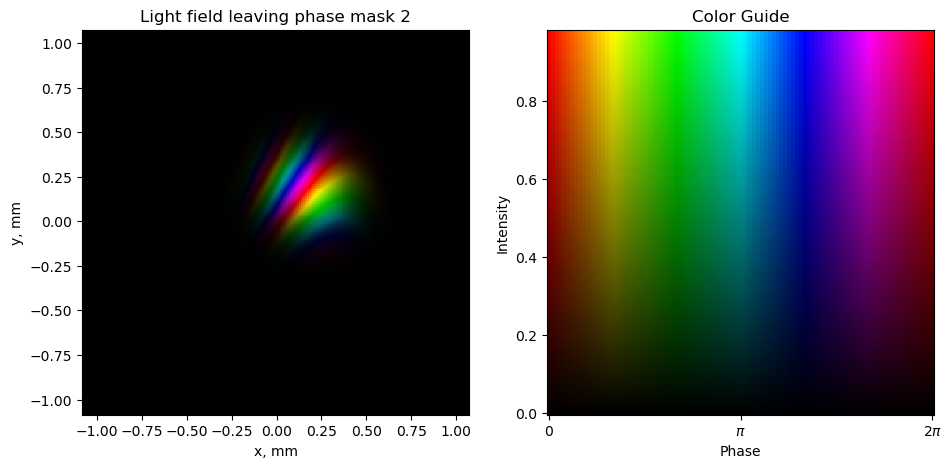

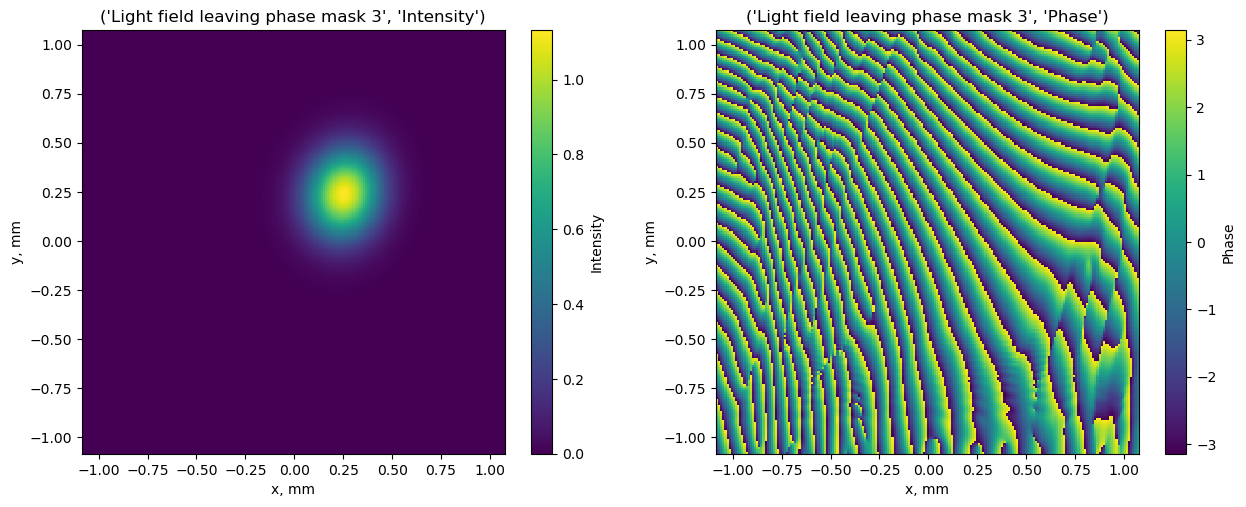

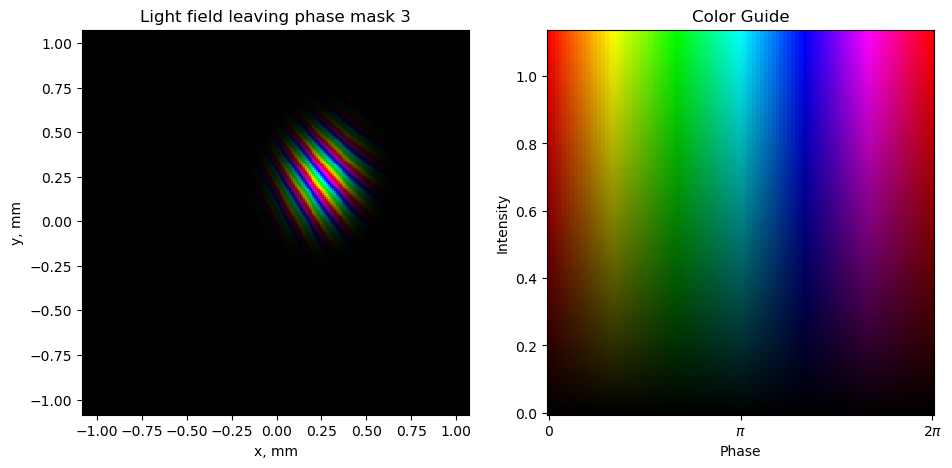

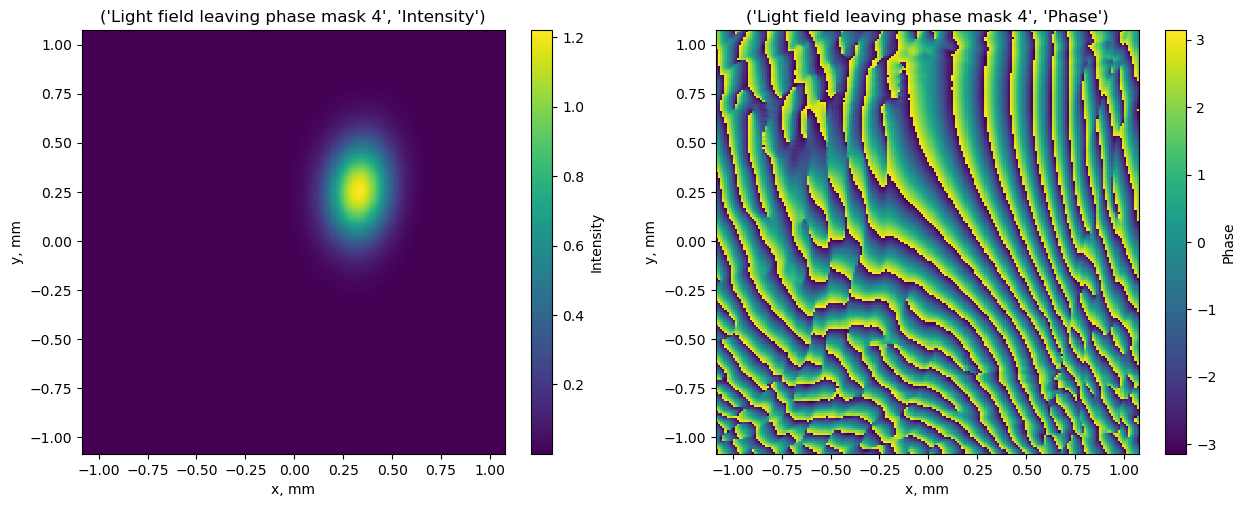

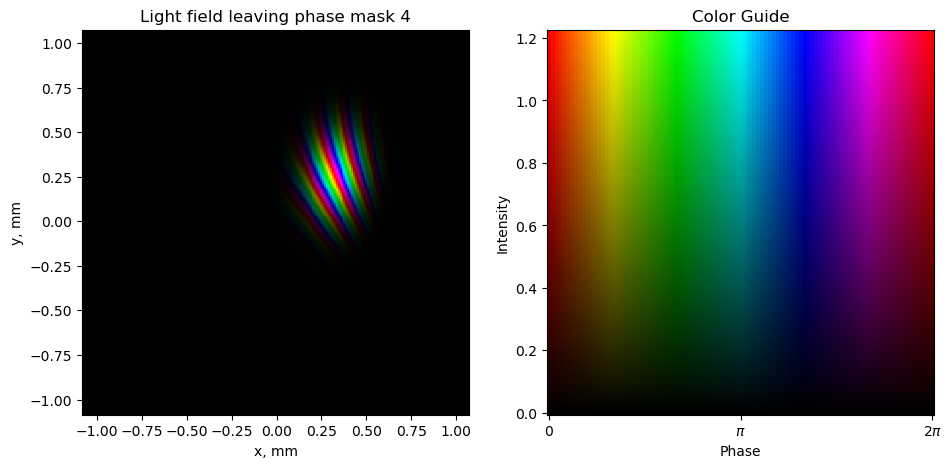

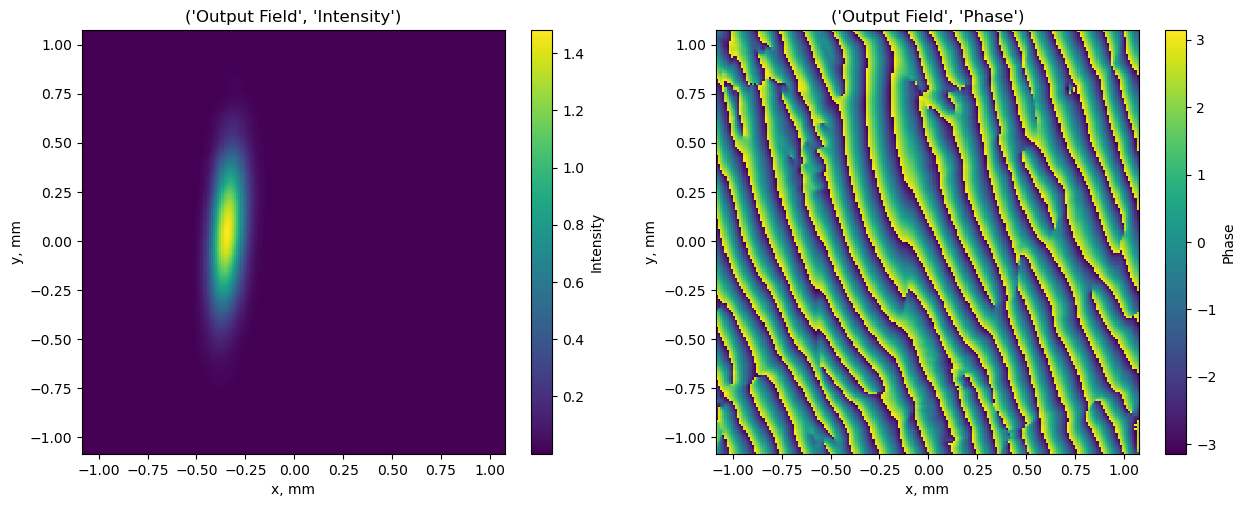

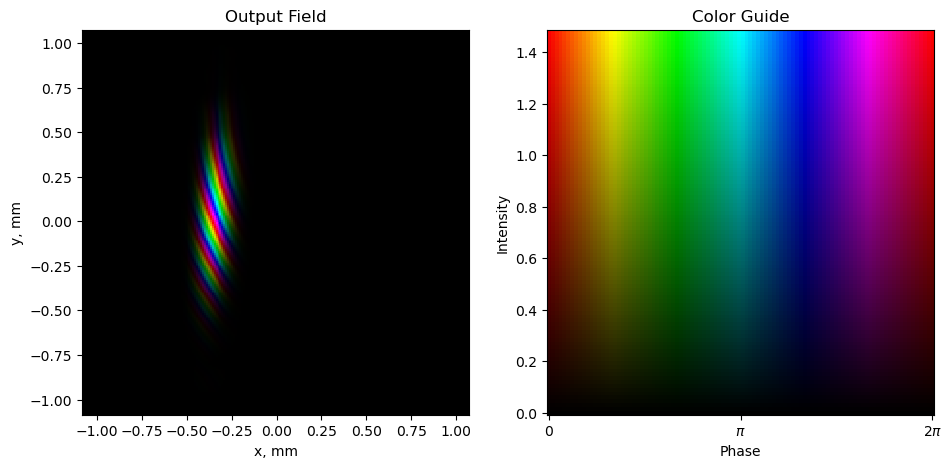

In [1]:
#Cell 1, forward model of a batch of identically misaligned systems with different phase masks
import torch#PyTorch
from torch.fft import fft2, ifft2, fftshift, ifftshift
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import cm

torch.autograd.set_detect_anomaly(True)

def get_device():
    """Automatically selects the best available GPU for parallelisation."""

    if torch.cuda.is_available():
        # PyTorch's ROCm build for AMD also reports as 'cuda' — distinguish via torch.version.hip
        if torch.version.hip is not None:
            print(f"AMD GPU detected (ROCm): {torch.cuda.get_device_name(0)}")
        else:
            print(f"NVIDIA GPU detected (CUDA): {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")

    elif torch.backends.mps.is_available():
        print("Apple Silicon GPU detected (MPS)")
        return torch.device("mps")

    elif hasattr(torch, "xpu") and torch.xpu.is_available():
        print(f"Intel GPU detected (XPU): {torch.xpu.get_device_name(0)}")
        return torch.device("xpu")

    else:
        print("No GPU found, falling back to CPU.")
        return torch.device("cpu")

device = get_device()
print(f"Using {device} device")

class MPLC:
    def __init__(self, wavelength, Npx, X, Y, PxWidth, distances=None, DeltaXs=None, DeltaYs=None, AberrationalTiltXs=None, AberrationalTiltYs=None,\
                 AberrationalDefocuses=None, AberrationalVerticalAstigmatisms=None, AberrationalObliqueAstigmatisms=None,\
                 AberrationalVerticalComas=None, AberrationalHorizontalComas=None, AberrationalVerticalTrefoils=None, AberrationalHorizontalTrefoils=None,\
                 BatchSize=1, IntendedTiltXs =None, IntendedTiltYs=None, IntendedDefocuses=None, IntendedVerticalAstigmatisms=None, IntendedObliqueAstigmatisms=None,\
                 IntendedVerticalComas=None, IntendedHorizontalComas=None, IntendedVerticalTrefoils=None, IntendedHorizontalTrefoils=None):

        self.Npx = Npx
        self.wavelength = wavelength
        self.k = 2 * torch.pi / wavelength
        self.PxWidth = PxWidth

        self.X, self.Y = (X, Y)

        if distances is None:
            # default distances (m) between planes
            self.distances = [30e-3]
        else:
            self.distances = distances

        if DeltaXs is None:
            self.DeltaXs = torch.zeros(len(distances+1))
        else:
            self.DeltaXs = DeltaXs

        if DeltaYs is None:
            self.DeltaYs = torch.zeros(len(distances+1))
        else:
            self.DeltaYs = DeltaYs

        if AberrationalTiltXs is None:
            self.AberrationalTiltXs = torch.zeros(len(distances))
        else:
            self.AberrationalTiltXs = AberrationalTiltXs

        if AberrationalTiltYs is None:
            self.AberrationalTiltYs = torch.zeros(len(distances))
        else:
            self.AberrationalTiltYs = AberrationalTiltYs

        if AberrationalDefocuses is None:
            self.AberrationalDefocuses = torch.zeros(len(distances))
        else:
            self.AberrationalDefocuses = AberrationalDefocuses

        if AberrationalVerticalAstigmatisms is None:
            self.AberrationalVerticalAstigmatisms = torch.zeros(len(distances))
        else:
            self.AberrationalVerticalAstigmatisms = AberrationalVerticalAstigmatisms

        if AberrationalObliqueAstigmatisms is None:
            self.AberrationalObliqueAstigmatisms = torch.zeros(len(distances))
        else:
            self.AberrationalObliqueAstigmatisms = AberrationalObliqueAstigmatisms

        if AberrationalVerticalComas is None:
            self.AberrationalVerticalComas = torch.zeros(len(distances))
        else:
            self.AberrationalVerticalComas = AberrationalVerticalComas
            
        if AberrationalHorizontalComas is None:
            self.AberrationalHorizontalComas = torch.zeros(len(distances))
        else:
            self.AberrationalHorizontalComas = AberrationalHorizontalComas

        if AberrationalVerticalTrefoils is None:
            self.AberrationalVerticalTrefoils = torch.zeros(len(distances))
        else:
            self.AberrationalVerticalTrefoils = AberrationalVerticalTrefoils

        if AberrationalHorizontalTrefoils is None:
            self.AberrationalHorizontalTrefoils = torch.zeros(len(distances))
        else:
            self.AberrationalHorizontalTrefoils = AberrationalHorizontalTrefoils

        if len(self.DeltaXs) != len(self.distances)+1 or len(self.DeltaYs) != len(self.distances)+1:
            raise ValueError("the number of lateral misalignments in x and y must each be 1 more than the number of distances to optimise")

        if IntendedTiltXs == None:
            IntendedTiltXDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedTiltXs) != (len(distances)) or len(IntendedTiltXs[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedTiltXDist = torch.stack([torch.stack([\
                (IntendedTiltX * self.X)\
                for IntendedTiltX in masknumber]) for masknumber in IntendedTiltXs])

        if IntendedTiltYs == None:
            IntendedTiltYDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedTiltYs) != (len(distances)) or len(IntendedTiltYs[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedTiltYDist = torch.stack([torch.stack([\
                (IntendedTiltY * self.Y)\
                for IntendedTiltY in masknumber]) for masknumber in IntendedTiltYs])
        
        if IntendedDefocuses == None:
            IntendedDefocusDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedDefocuses) != (len(distances)) or len(IntendedDefocuses[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedDefocusDist = torch.stack([torch.stack([\
                (IntendedDefocus * (self.X**2+self.Y**2))\
                for IntendedDefocus in masknumber]) for masknumber in IntendedDefocuses])

        if IntendedVerticalAstigmatisms == None:
            IntendedVerticalAstigmaticDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedVerticalAstigmatisms) != (len(distances)) or len(IntendedVerticalAstigmatisms[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedVerticalAstigmaticDist = torch.stack([torch.stack([\
                (IntendedVerticalAstigmatism * (self.X**2-self.Y**2))\
                for IntendedVerticalAstigmatism in masknumber]) for masknumber in IntendedVerticalAstigmatisms])

        if IntendedObliqueAstigmatisms == None:
            IntendedObliqueAstigmaticDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedObliqueAstigmatisms) != (len(distances)) or len(IntendedObliqueAstigmatisms[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedObliqueAstigmaticDist = torch.stack([torch.stack([\
                (IntendedObliqueAstigmatism * 2 * self.X * self.Y)\
                for IntendedObliqueAstigmatism in masknumber]) for masknumber in IntendedObliqueAstigmatisms])

        if IntendedVerticalComas == None:
            IntendedVerticalComaDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedVerticalComas) != (len(distances)) or len(IntendedVerticalComas[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedVerticalComaDist = torch.stack([torch.stack([\
                (IntendedVerticalComa * (self.Y**3*3 + self.X**2*self.Y*3 - Y * (Npx*PxWidth/2)**2) / 2)\
                for IntendedVerticalComa in masknumber]) for masknumber in IntendedVerticalComas])

        if IntendedHorizontalComas == None:
            IntendedHorizontalComaDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedHorizontalComas) != (len(distances)) or len(IntendedHorizontalComas[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedHorizontalComaDist = torch.stack([torch.stack([\
                (IntendedHorizontalComa * (self.X**3*3 + self.Y**2*self.X*3 - X * (Npx*PxWidth/2)**2) / 2)\
                for IntendedHorizontalComa in masknumber]) for masknumber in IntendedHorizontalComas])

        if IntendedVerticalTrefoils == None:
            IntendedVerticalTrefoilDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedVerticalTrefoils) != (len(distances)) or len(IntendedVerticalTrefoils[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedVerticalTrefoilDist = torch.stack([torch.stack([\
                (IntendedVerticalTrefoil * (-self.Y**3 + 3*self.X**2*self.Y))\
                for IntendedVerticalTrefoil in masknumber]) for masknumber in IntendedVerticalTrefoils])

        if IntendedHorizontalTrefoils == None:
            IntendedHorizontalTrefoilDist = torch.zeros(len(distances),BatchSize,Npx,Npx).to(device)
        else:
            if len(IntendedHorizontalTrefoils) != (len(distances)) or len(IntendedHorizontalTrefoils[0]) != (BatchSize):# or len(masks[0][0]) != Npx or len(masks[0][0][0]) != Npx
                raise ValueError("masks must have dimensions BatchSize * Nmasks * Npx * Npx")
            IntendedHorizontalTrefoilDist = torch.stack([torch.stack([\
                (IntendedHorizontalTrefoil * (self.X**3 - 3*self.Y**2*self.X))\
                for IntendedHorizontalTrefoil in masknumber]) for masknumber in IntendedHorizontalTrefoils])
        
        # add Zernike modes
        AberrationalTiltDist = torch.stack([torch.stack([\
            (self.AberrationalTiltXs[i] * self.X + self.AberrationalTiltYs[i] * self.Y) for _ in range(BatchSize)]) for i in range(len(distances))])
            
        AberrationalDefocusDist = torch.stack([torch.stack([\
            (self.AberrationalDefocuses[i] * (self.X**2+self.Y**2)) for _ in range(BatchSize)]) for i in range(len(distances))])
        AberrationalAstigmaticDist = torch.stack([torch.stack([\
            (self.AberrationalObliqueAstigmatisms[i] * 2 * self.X * self.Y + self.AberrationalVerticalAstigmatisms[i] * (self.X**2 - self.Y**2))\
            for _ in range(BatchSize)]) for i in range(len(distances))])

        AberrationalComaDist = torch.stack([torch.stack([\
            (self.AberrationalVerticalComas[i] * (3 * self.Y**3 + 3*self.X**2*self.Y - Y*(Npx*PxWidth/2)**2) / 2 + self.AberrationalHorizontalComas[i] * (3*self.X**3 + 3*self.Y**2*self.X - self.X*(Npx*PxWidth/2)**2 /2))\
            for _ in range(BatchSize)]) for i in range(len(distances))])
        AberrationalTrefoilDist = torch.stack([torch.stack([\
            (self.AberrationalVerticalTrefoils[i] * (-self.Y**3 + 3*self.X**2*self.Y) + self.AberrationalHorizontalTrefoils[i] * (self.X**3 - 3*self.Y**2*self.X))\
            for _ in range(BatchSize)]) for i in range(len(distances))])

        self.aberrations = (AberrationalTiltDist + AberrationalDefocusDist + AberrationalAstigmaticDist + AberrationalComaDist + AberrationalTrefoilDist) * 2 * self.k
        self.masks = (IntendedTiltXDist + IntendedTiltYDist + IntendedDefocusDist + IntendedVerticalAstigmaticDist + IntendedObliqueAstigmaticDist + IntendedVerticalComaDist\
                      + IntendedHorizontalComaDist + IntendedVerticalTrefoilDist + IntendedHorizontalTrefoilDist) * 2 * self.k + self.aberrations

        # precompute frequency grids for angular spectrum
        k_x = torch.arange(-Npx/2, Npx/2).to(device) * 2 * torch.pi / (Npx * PxWidth)
        k_y = torch.arange(-Npx/2, Npx/2).to(device) * 2 * torch.pi / (Npx * PxWidth)
        self.kx, self.ky = torch.meshgrid(k_x, k_y)
        self.kz = torch.sqrt(self.k**2 - self.kx**2 - self.ky**2 + torch.tensor(0j)).to(device)

    def propagate(self, Field_in, DeltaZ, DX, DY):
        """Angular-spectrum propagation of Field_in over free space.

        Field_in: 2D complex pixel array (N x N)
        Deltas: propagation vector (x, y and z) in meters
        returns: Field_out (2D complex)
        """
        InitialAngularSpectrum = fftshift(fft2(ifftshift(Field_in))).to(device)
        H = torch.exp(1j * (self.kz * DeltaZ + self.kx * DX + self.ky * DY)).to(device)

        # Propagate
        NewAngularSpectrum = InitialAngularSpectrum * H
        Field_out = fftshift(ifft2(ifftshift(NewAngularSpectrum)))#field arriving at next plane (Before phase mask)
        return Field_out

    def forward(self, Beam):
        """Run forward propagation through a single N-plane MPLC
        Return intermediate fields
        Strictly useful for graphing

        Sequence:
          Beam -> apply mask 1 -> propagate to mask 2 -> apply mask2 -> ... -> u_out

        Beam: complex input field (N x N)
        return_intermediate: if True, also return list of fields after each plane

        returns: list of 2D complex fields
        """

        Fields_sequence = []
        Field = Beams[0]

        Fields_sequence.append(Field.cpu().detach())
        Field = self.propagate(Field,0,self.DeltaXs[0],self.DeltaYs[0])
        for i in range(len(self.distances)):
            Field *= torch.exp(1j * self.masks[i][0])
            Fields_sequence.append(Field.cpu().detach())
            Field = self.propagate(Field, self.distances[i],self.DeltaXs[i+1],self.DeltaYs[i+1])
            #distances array starts at first phase mask. Lateral misalignments do not.

        Fields_sequence.append(Field.cpu().detach())
        return Fields_sequence#Field_output

    def fieldsout(self, Beam):
        """Run parallelised forward propagation through multiple N-plane MPLCs
        Do not return intermediate fields
        Strictly useful for optimiser training data

        Sequence:
          Beams -> apply mask 1 -> propagate to mask 2 -> apply mask2 -> ... -> Fields_out

        Beam: complex input field (N x N)
        return_intermediate: if True, also return list of fields after each plane

        returns: list of 2D complex fields
        """
        #propagate an array of fields through an array of different MPLCs in parallel
        Fields = Beams
        Fields = self.propagate(Fields,0,self.DeltaXs[0],self.DeltaYs[0])

        for i in range(len(self.distances)):
            Fields *= torch.exp(1j * self.masks[i])
            Fields = self.propagate(Fields, self.distances[i],self.DeltaXs[i+1]-self.DeltaXs[i],self.DeltaYs[i+1]-self.DeltaYs[i])

        #normalise outputs so we can see how bad the losses are
        Fields /= torch.stack(([torch.tensor([[(torch.nansum(torch.abs(Fields[i])**4))**0.25]]) for i in range(BatchSize)])).to(device)

        return Fields

# --------------------------- Example usage -----------------------------
if __name__ == '__main__':
    def H(n):
        """Return numpy.poly1d Hermite polynomial."""
        if n == 0:
            return np.poly1d([1])
        if n == 1:
            return np.poly1d([2, 0])

        H_nm1 = np.poly1d([1])     # H_{n-1}
        H_n   = np.poly1d([2, 0])  # H_n
        for k in range(1, n):#recursive relation
            H_np1 = 2*np.poly1d([1, 0]) * H_n - 2*k * H_nm1 #H_{n+1}
            H_nm1, H_n = H_n, H_np1
        return H_n

    def HermiteGaussian(n_x,n_y,X,Y,w0):
        """Generate Hermite Gaussian input beam""" #not needed over simple Gaussians but could increase resolution
        X = X.cpu().detach().numpy()
        Y = Y.cpu().detach().numpy()
        H_x = H(n_x)
        H_y = H(n_y)
        return np.exp(-(X**2 + Y**2) / w0**2)* H_x(np.sqrt(2)*X/w0) * H_y(np.sqrt(2)*Y/w0)

    def FieldToRGB(Field):
        """Allows fields to be displayed in the Hue Saturation Veracity spectrum. Needs to be on cpu for matplotlib."""
        Intensity = np.abs(Field)**2
        MaxIntensity = Intensity.max()
        RelativeIntensity = Intensity/ MaxIntensity
        Phase = np.angle(Field)
        FieldH = (Phase / (2*np.pi)) % 1
        FieldS = np.ones((Npx,Npx))
        FieldV = RelativeIntensity
        FieldHSV = [[[h, s, v] for h, s, v in zip(r1, r2, r3)] for r1, r2, r3 in zip(FieldH, FieldS, FieldV)]
        return matplotlib.colors.hsv_to_rgb(FieldHSV)

    def ReferenceField(Field):
        """Colour guide for FieldToRGB"""
        MaxMagnitude = Field.abs().max()
        Phase, Magnitude = torch.meshgrid(torch.linspace(0, 2*np.pi,100),torch.linspace(0, MaxMagnitude) * PixelSize)
        ReferenceField = Magnitude * torch.exp(1j * Phase)

    #parameters
    #use default parameters, as they are correct for the setup
    StandardDistance = 30e-3
    wavelength = 633e-9
    k = 2*torch.pi/wavelength
    Npx = 200
    PxWidth = 10.8e-6 #metres
    DesiredDistances = torch.tensor([30e-3,30e-3,30e-3,120e-3])#Interplanar distances are 30mm when mirrors are considered. Camera is 120mm away.
    Nmasks = len(DesiredDistances.tolist())# n phase masks per MPLC
    #lateral misalignments in the phase masks
    DeltaXs   = (torch.rand(Nmasks+1)-0.5) * 200e-6 #up to 100 microns either way
    DeltaYs   = (torch.rand(Nmasks+1)-0.5) * 200e-6 #these will be relative to the axis of the input laser, not relative to each other
    distances = (torch.rand(Nmasks)-0.5) * 20e-3 + DesiredDistances #up to 10mm either way
    
    #First order Zernike Modes
    #Not in use
    AberrationalTiltXs = torch.zeros(Nmasks) #(torch.rand(Nmasks)-0.5) * 200e-6#we can't distinguish this from lateral misalignment...
    AberrationalTiltYs = torch.zeros(Nmasks) #(torch.rand(Nmasks)-0.5) * 200e-6#...but that's how we can compensate for tilts
    #we can achieve the same low losses from the optimisation if we add tilts to the forward model
    #we cannot accurately measure tilt when lateral misalignment is not known and vice versa

    #Second order Zernike Modes
    AberrationalDefocuses            = (torch.rand(Nmasks)-0.5) #torch.zeros(Nmasks)#
    AberrationalVerticalAstigmatisms = (torch.rand(Nmasks)-0.5) #torch.zeros(Nmasks)#
    AberrationalObliqueAstigmatisms  = (torch.rand(Nmasks)-0.5) #torch.zeros(Nmasks)#

    #Third order Zernike modes
    AberrationalVerticalComas      = (torch.rand(Nmasks)-0.5) * 100
    AberrationalHorizontalComas    = (torch.rand(Nmasks)-0.5) * 100
    AberrationalVerticalTrefoils   = (torch.rand(Nmasks)-0.5) * 100
    AberrationalHorizontalTrefoils = (torch.rand(Nmasks)-0.5) * 100

    BatchSize = 42 # n MPLCs in the forward model, allowing for the more accurate batch gradient descent

    x = torch.arange(-Npx/2, Npx/2).to(device) * PxWidth#positions of pixels
    y = torch.arange(-Npx/2, Npx/2).to(device) * PxWidth
    X, Y = torch.meshgrid(x, y)
    r2 = X**2 + Y**2
    Xmm, Ymm = (X*1000, Y*1000)

    # initialize masks
    # make sure they are the same for the forward and backward model
    IntendedTiltXs = (torch.rand(Nmasks,BatchSize)-0.5) * 0.01
    IntendedTiltYs = (torch.rand(Nmasks,BatchSize)-0.5) * 0.01

    IntendedDefocuses = (torch.rand(Nmasks,BatchSize)-0.5) 
    IntendedVerticalAstigmatisms = (torch.rand(Nmasks,BatchSize)-0.5) 
    IntendedObliqueAstigmatisms = (torch.rand(Nmasks,BatchSize)-0.5) 

    IntendedVerticalComas = (torch.rand(Nmasks,BatchSize)-0.5) * 100
    IntendedHorizontalComas = (torch.rand(Nmasks,BatchSize)-0.5) * 100
    IntendedVerticalTrefoils = (torch.rand(Nmasks,BatchSize)-0.5) * 100
    IntendedHorizontalTrefoils = (torch.rand(Nmasks,BatchSize)-0.5) * 100

    #Remove tilts from last phase mask as it cannot be corrected for, and contributes nothing to convergence
    IntendedTiltXs[-1] *= 0
    IntendedTiltYs[-1] *= 0
    
    #Correct for the remaining tilts so we don't get aliasing
    #Don't change tilts until all corrections are correctly calculated
    CorrectionalTiltXs = np.zeros((Nmasks,BatchSize))
    CorrectionalTiltYs = np.zeros((Nmasks,BatchSize))
    for i in range(Nmasks-1):
        CorrectionalTiltXs[i+1] = IntendedTiltXs[i] * torch.sum(DesiredDistances[i:])/torch.sum(DesiredDistances[i+1:])#bends light back towards camera
        CorrectionalTiltYs[i+1] = IntendedTiltYs[i] * torch.sum(DesiredDistances[i:])/torch.sum(DesiredDistances[i+1:])
    
    IntendedTiltXs -= CorrectionalTiltXs
    IntendedTiltYs -= CorrectionalTiltYs

    # instantiate MPLC
    mplcGroundTruth = MPLC(wavelength=wavelength, Npx=Npx, X=X, Y=Y, PxWidth=PxWidth,\
                           distances=distances, DeltaXs=DeltaXs, DeltaYs=DeltaYs,\
                           AberrationalTiltXs=AberrationalTiltXs, AberrationalTiltYs=AberrationalTiltYs,\
                           AberrationalDefocuses=AberrationalDefocuses,\
                           AberrationalVerticalAstigmatisms=AberrationalVerticalAstigmatisms,\
                           AberrationalObliqueAstigmatisms=AberrationalObliqueAstigmatisms,\
                           AberrationalVerticalComas=AberrationalVerticalComas,\
                           AberrationalHorizontalComas=AberrationalHorizontalComas,\
                           AberrationalVerticalTrefoils=AberrationalVerticalTrefoils,\
                           AberrationalHorizontalTrefoils=AberrationalHorizontalTrefoils,\
                           BatchSize=BatchSize, IntendedTiltXs=IntendedTiltXs,\
                           IntendedTiltYs=IntendedTiltYs, IntendedDefocuses=IntendedDefocuses,\
                           IntendedVerticalAstigmatisms=IntendedVerticalAstigmatisms,\
                           IntendedObliqueAstigmatisms=IntendedObliqueAstigmatisms,\
                           IntendedVerticalComas=IntendedVerticalComas,\
                           IntendedHorizontalComas=IntendedHorizontalComas,\
                           IntendedVerticalTrefoils=IntendedVerticalTrefoils,\
                           IntendedHorizontalTrefoils=IntendedHorizontalTrefoils)

    # create Hermite-Gaussian inputs (waist 300 um)
    w0 = 300e-6
    x0 = 0
    y0 = 0
    amplitude = 1
    n_x = torch.randint(1,(BatchSize,))#stack of zeros
    n_y = torch.randint(1,(BatchSize,))#when n_x and n_y are 0, it produces a gaussian beam

    #Generate hermite-gaussian beams
    Beams = torch.stack([torch.tensor(HermiteGaussian(n_x[i],n_y[i],X,Y,w0)) for i in range(BatchSize)]).to(device)
    #can be made to generate random hermite gaussians, eg. n_x = torch.randint(2,(BatchSize,))

    # run forward model
    Fields_sequence = mplcGroundTruth.forward(Beams)

    # show intensity at input, after plane 0, after plane 1, after plane 2, after plane 3, output
    captions = ["Input beam"]
    for i in range(Nmasks):
        captions.append(f"Light field leaving phase mask {i+1}")
    captions.append("Output Field")

    Fields_sequence_CPU = np.array(Fields_sequence)
    #Fields is still a gpu pytorch tensor. FieldsCPU is a CPU numpy list (so matplotlib can use it)
    XmmCPU = Xmm.cpu().detach().numpy()
    YmmCPU = Ymm.cpu().detach().numpy()

    for i in range(len(Fields_sequence_CPU)):
        fig, (ax1,ax2) = plt.subplots(1,2, figsize = (15,5.5))
        im1 = ax1.pcolormesh(XmmCPU,YmmCPU,np.abs(Fields_sequence_CPU[i])**2)#intensity
        im2 = ax2.pcolormesh(XmmCPU,YmmCPU,np.angle(Fields_sequence_CPU[i]))#phase
        ax1.set_title(label = (captions[i], 'Intensity'))
        ax2.set_title(label = (captions[i], 'Phase'))
        fig.colorbar(im1, ax=ax1, label='Intensity')
        fig.colorbar(im2, ax=ax2, label='Phase')
        ax1.set_xlabel('x, mm')
        ax2.set_xlabel('x, mm')
        ax1.set_ylabel('y, mm')
        ax2.set_ylabel('y, mm')
        plt.show()

        fig, (ax1,ax2) = plt.subplots(1,2, figsize = (11,5))
        im1 = ax1.pcolormesh(XmmCPU,YmmCPU,FieldToRGB(Fields_sequence_CPU[i]))
        #plot colour of phase and intensity for reference
        MaxIntensity = np.max(np.abs(Fields_sequence_CPU[i]))**2
        Phase, Intensity = np.meshgrid(np.linspace(0, 2*np.pi,100),np.linspace(0, MaxIntensity,100))
        ReferenceField = np.sqrt(Intensity) * np.exp(1j * Phase)#magnitude and phase
        im2 = ax2.pcolormesh(Phase,Intensity,FieldToRGB(ReferenceField))
        ax1.set_title(label = captions[i])
        ax1.set_xlabel('x, mm')
        ax1.set_ylabel('y, mm')
        ax2.set_title(label = 'Color Guide')
        ax2.set_xlabel('Phase')
        ax2.set_ylabel('Intensity')
        ax2.set_xticks([0,np.pi,2*np.pi])
        ax2.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'])
        plt.show()

Let's say all tilts are zero
Completed 0 steps. Loss: 9.4397e-01  LRs: ['1.00e-04', '2.00e-05', '2.00e-05', '2.00e-02', '2.00e-02', '2.00e-02', '5.00e+00', '5.00e+00', '5.00e+00', '5.00e+00']

Step 0, Loss: 0.9439713358879089 
distances: [30.0, 30.0, 30.0, 120.0]mm         
DeltaXs: [0.0, 0.0, 0.0, 0.0, 0.0]µm 
DeltaYs: [0.0, 0.0, 0.0, 0.0, 0.0]µm         
Defocuses: [0.0, 0.0, 0.0, 0.0] 
VerticalAstigmatisms: [0.0, 0.0, 0.0, 0.0]         
ObliqueAstigmatisms: [0.0, 0.0, 0.0, 0.0]         
VerticalComas: [0.0, 0.0, 0.0, 0.0]         
HorizontalComas: [0.0, 0.0, 0.0, 0.0]         
VerticalTrefoils: [0.0, 0.0, 0.0, 0.0]         
HorizontalTrefoils: [0.0, 0.0, 0.0, 0.0]

Completed 100 steps. Loss: 8.4539e-03  LRs: ['9.78e-05', '1.96e-05', '1.96e-05', '1.96e-02', '1.96e-02', '1.96e-02', '4.89e+00', '4.89e+00', '4.89e+00', '4.89e+00']
Completed 200 steps. Loss: 1.9195e-03  LRs: ['9.15e-05', '1.83e-05', '1.83e-05', '1.83e-02', '1.83e-02', '1.83e-02', '4.57e+00', '4.57e+00', '4.57e+00', '4.57

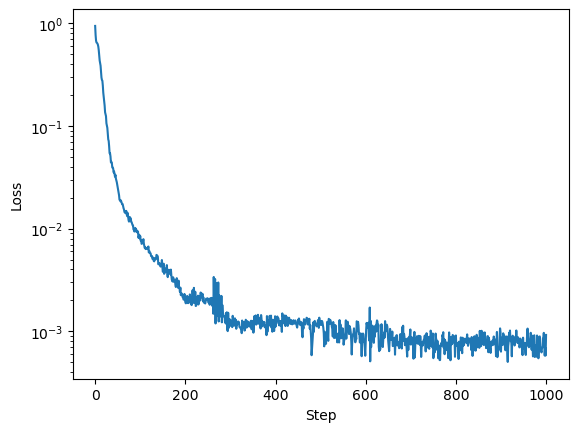

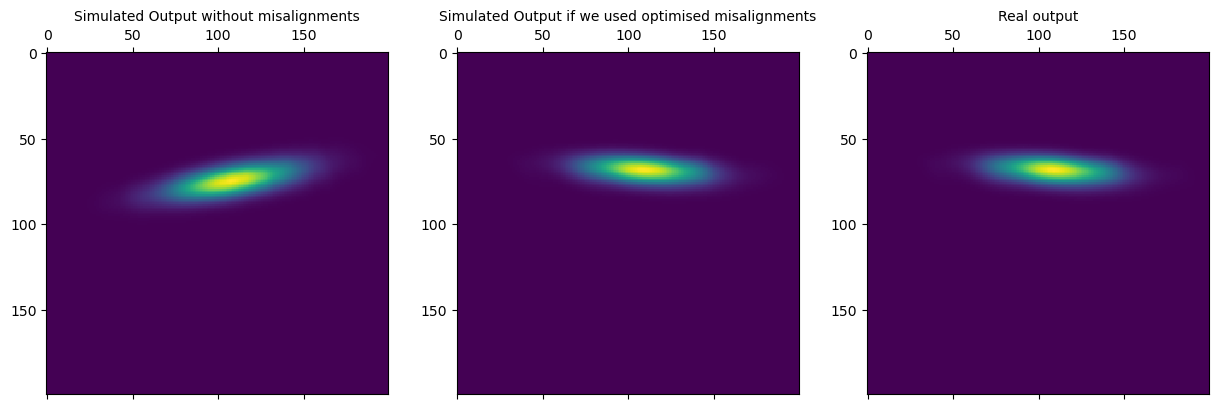

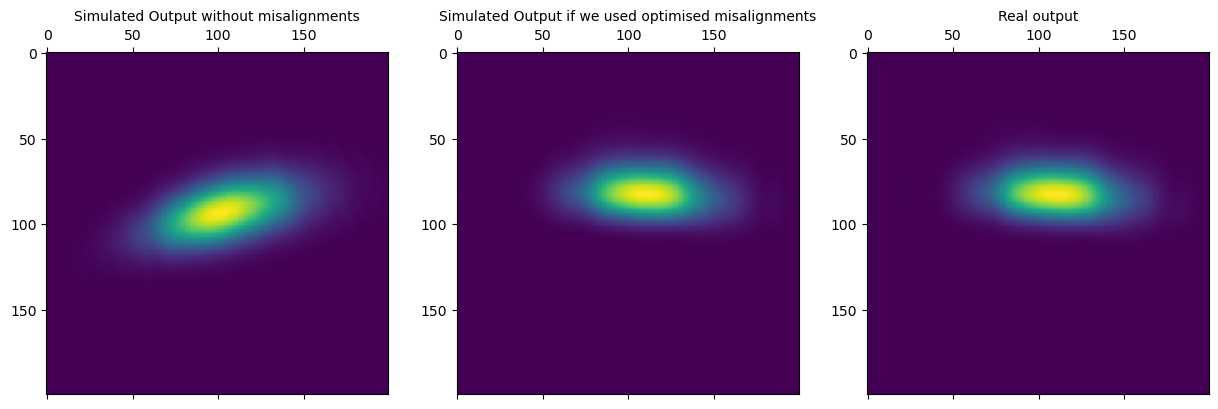

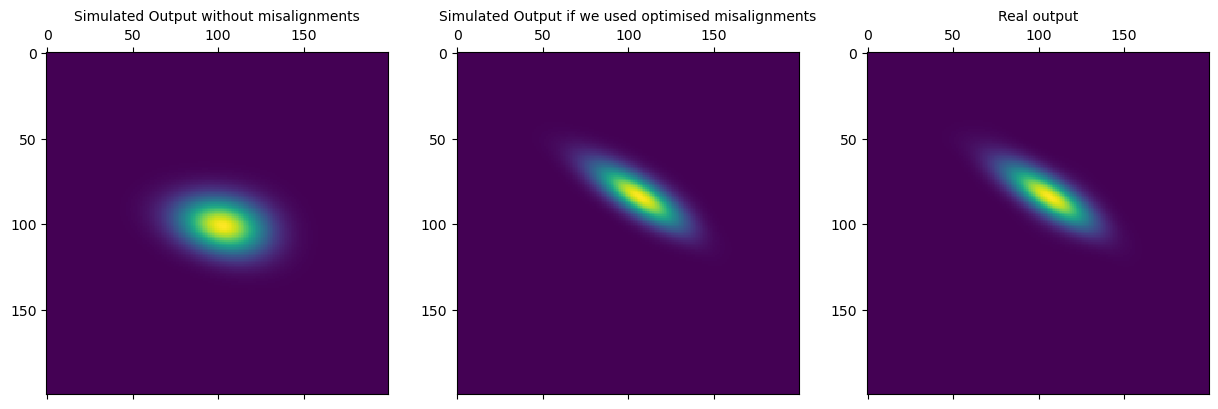

In [2]:
#Cell 2, optimisation of the misalignment parameters through batch gradient descent
import torch.optim as optim

FieldsOutGroundTruth = mplcGroundTruth.fieldsout(Beams)

#change parameters to those of a correctly-aligned system as a first guess
distances = torch.nn.Parameter(DesiredDistances)#Guess = 30mm,30mm,30mm,120mm
DeltaXs   = torch.nn.Parameter(torch.zeros(Nmasks+1))#up to 500 microns either way
DeltaYs   = torch.nn.Parameter(torch.zeros(Nmasks+1))
AberrationalTiltXs = torch.nn.Parameter(torch.zeros(Nmasks))#we can't distinguish tilts from lateral misalignment...
AberrationalTiltYs = torch.nn.Parameter(torch.zeros(Nmasks))#...and we won't optimise them
AberrationalDefocuses            = torch.nn.Parameter(torch.zeros(Nmasks))
AberrationalVerticalAstigmatisms = torch.nn.Parameter(torch.zeros(Nmasks))
AberrationalObliqueAstigmatisms  = torch.nn.Parameter(torch.zeros(Nmasks))
AberrationalVerticalComas      = torch.nn.Parameter(torch.zeros(Nmasks))
AberrationalHorizontalComas    = torch.nn.Parameter(torch.zeros(Nmasks))
AberrationalVerticalTrefoils   = torch.nn.Parameter(torch.zeros(Nmasks))
AberrationalHorizontalTrefoils = torch.nn.Parameter(torch.zeros(Nmasks))

#Score outputs
def SquareErrorLoss(TargetOutput,MeasuredOutput):
    """Score total intensity errors in the output planes"""
    SquareError = (torch.add(TargetOutput.abs()**2,-MeasuredOutput.abs()**2))**2
    return torch.nansum(SquareError)

def FindBatchLoss(FieldsOutGroundTruth, Beams, wavelength, Npx, X, Y, PxWidth,\
                           distances, DeltaXs, DeltaYs, AberrationalTiltXs, AberrationalTiltYs,\
                           AberrationalDefocuses, AberrationalVerticalAstigmatisms, AberrationalObliqueAstigmatisms,\
                           AberrationalVerticalComas, AberrationalHorizontalComas, AberrationalVerticalTrefoils,\
                           AberrationalHorizontalTrefoils, BatchSize, IntendedDefocuses, IntendedVerticalAstigmatisms,\
                           IntendedObliqueAstigmatisms, IntendedVerticalComas, IntendedHorizontalComas,\
                           IntendedVerticalTrefoils, IntendedHorizontalTrefoils):
    """Simulates MPLC with given parameters and scores how well its outputs match the ground truth outputs"""
    mplcGuess = MPLC(wavelength=wavelength, Npx=Npx, X=X, Y=Y, PxWidth=PxWidth,\
                           distances=distances, DeltaXs=DeltaXs, DeltaYs=DeltaYs,\
                           AberrationalTiltXs=AberrationalTiltXs, AberrationalTiltYs=AberrationalTiltYs,\
                           AberrationalDefocuses=AberrationalDefocuses,\
                           AberrationalVerticalAstigmatisms=AberrationalVerticalAstigmatisms,\
                           AberrationalObliqueAstigmatisms=AberrationalObliqueAstigmatisms,\
                           AberrationalVerticalComas=AberrationalVerticalComas,\
                           AberrationalHorizontalComas=AberrationalHorizontalComas,\
                           AberrationalVerticalTrefoils=AberrationalVerticalTrefoils,\
                           AberrationalHorizontalTrefoils=AberrationalHorizontalTrefoils,\
                           BatchSize=BatchSize, IntendedTiltXs=IntendedTiltXs,\
                           IntendedTiltYs=IntendedTiltYs, IntendedDefocuses=IntendedDefocuses,\
                           IntendedVerticalAstigmatisms=IntendedVerticalAstigmatisms,\
                           IntendedObliqueAstigmatisms=IntendedObliqueAstigmatisms,\
                           IntendedVerticalComas=IntendedVerticalComas,\
                           IntendedHorizontalComas=IntendedHorizontalComas,\
                           IntendedVerticalTrefoils=IntendedVerticalTrefoils,\
                           IntendedHorizontalTrefoils=IntendedHorizontalTrefoils)

    FieldsOutGuess = mplcGuess.fieldsout(Beams)
    loss = SquareErrorLoss(FieldsOutGroundTruth,FieldsOutGuess)/BatchSize
    return loss

#Optimise parameters
lr_z  = 1e-4
lr_xy = 2e-5
lr_2nd = 2e-2
lr_3rd = 5

optimiser = optim.Adam([
    {'params': distances, 'lr': lr_z},
    {'params': DeltaXs, 'lr': lr_xy},
    {'params': DeltaYs, 'lr': lr_xy},
    {'params': AberrationalDefocuses, 'lr': lr_2nd},
    {'params': AberrationalVerticalAstigmatisms, 'lr': lr_2nd},
    {'params': AberrationalObliqueAstigmatisms, 'lr': lr_2nd},
    {'params': AberrationalVerticalComas, 'lr': lr_3rd},
    {'params': AberrationalHorizontalComas, 'lr': lr_3rd},
    {'params': AberrationalVerticalTrefoils, 'lr': lr_3rd},
    {'params': AberrationalHorizontalTrefoils, 'lr': lr_3rd},
])
# Store initial learning rates once, before the loop
initial_lrs = [group['lr'] for group in optimiser.param_groups]
RelativeMinimumLr = 0.1

Steps = 1001

losses = np.zeros((Steps,1))
distancesStack = np.zeros((Steps,Nmasks))+30e-6
DeltaXsStack = np.zeros((Steps,Nmasks+1))
DeltaYsStack = np.zeros((Steps,Nmasks+1))
AberrationalDefocusesStack = np.zeros((Steps,Nmasks))
AberrationalVerticalAstigmatismsStack = np.zeros((Steps,Nmasks))
AberrationalObliqueAstigmatismsStack  = np.zeros((Steps,Nmasks))
AberrationalVerticalComasStack      = np.zeros((Steps,Nmasks))
AberrationalHorizontalComasStack    = np.zeros((Steps,Nmasks))
AberrationalVerticalTrefoilsStack   = np.zeros((Steps,Nmasks))
AberrationalHorizontalTrefoilsStack = np.zeros((Steps,Nmasks))


StartGuess = MPLC(wavelength=wavelength, Npx=Npx, X=X, Y=Y, PxWidth=PxWidth,\
                           distances=distances, DeltaXs=DeltaXs, DeltaYs=DeltaYs,\
                           AberrationalTiltXs=AberrationalTiltXs, AberrationalTiltYs=AberrationalTiltYs,\
                           AberrationalDefocuses=AberrationalDefocuses,\
                           AberrationalVerticalAstigmatisms=AberrationalVerticalAstigmatisms,\
                           AberrationalObliqueAstigmatisms=AberrationalObliqueAstigmatisms,\
                           AberrationalVerticalComas=AberrationalVerticalComas,\
                           AberrationalHorizontalComas=AberrationalHorizontalComas,\
                           AberrationalVerticalTrefoils=AberrationalVerticalTrefoils,\
                           AberrationalHorizontalTrefoils=AberrationalHorizontalTrefoils,\
                           BatchSize = BatchSize, IntendedTiltXs=IntendedTiltXs,\
                           IntendedTiltYs=IntendedTiltYs, IntendedDefocuses=IntendedDefocuses,\
                           IntendedVerticalAstigmatisms=IntendedVerticalAstigmatisms,\
                           IntendedObliqueAstigmatisms=IntendedObliqueAstigmatisms,\
                           IntendedVerticalComas=IntendedVerticalComas,\
                           IntendedHorizontalComas=IntendedHorizontalComas,\
                           IntendedVerticalTrefoils=IntendedVerticalTrefoils,\
                           IntendedHorizontalTrefoils=IntendedHorizontalTrefoils)
StartFieldOut = StartGuess.fieldsout(Beams)

print("Let's say all tilts are zero")

for step in range(Steps):
    optimiser.zero_grad()
    loss = FindBatchLoss(FieldsOutGroundTruth, Beams, wavelength, Npx, X, Y, PxWidth,\
                           distances, DeltaXs, DeltaYs, AberrationalTiltXs, AberrationalTiltYs,\
                           AberrationalDefocuses, AberrationalVerticalAstigmatisms, AberrationalObliqueAstigmatisms,\
                           AberrationalVerticalComas, AberrationalHorizontalComas, AberrationalVerticalTrefoils,\
                           AberrationalHorizontalTrefoils, BatchSize, IntendedDefocuses, IntendedVerticalAstigmatisms,\
                           IntendedObliqueAstigmatisms, IntendedVerticalComas, IntendedHorizontalComas,\
                           IntendedVerticalTrefoils, IntendedHorizontalTrefoils)

    if step % 100 == 0:
        current_lrs = [f"{g['lr']:.2e}" for g in optimiser.param_groups]
        print(f'Completed {step} steps. Loss: {loss.item():.4e}  LRs: {current_lrs}')
    if step % (Steps-1) == 0:#once at the start, once at the end
        print(f"\nStep {step}, Loss: {loss.item()} \ndistances: {(distances*1000).tolist()}mm \
        \nDeltaXs: {(DeltaXs*1e6).tolist()}µm \nDeltaYs: {(DeltaYs*1e6).tolist()}µm \
        \nDefocuses: {AberrationalDefocuses.tolist()} \nVerticalAstigmatisms: {AberrationalVerticalAstigmatisms.tolist()} \
        \nObliqueAstigmatisms: {AberrationalObliqueAstigmatisms.tolist()} \
        \nVerticalComas: {AberrationalVerticalComas.tolist()} \
        \nHorizontalComas: {AberrationalHorizontalComas.tolist()} \
        \nVerticalTrefoils: {AberrationalVerticalTrefoils.tolist()} \
        \nHorizontalTrefoils: {AberrationalHorizontalTrefoils.tolist()}\n")
    
    losses[step] = loss.detach().cpu().numpy()
    
    distancesStack[step] = distances.detach().cpu().numpy()
    DeltaXsStack[step] = DeltaXs.detach().cpu().numpy()
    DeltaYsStack[step] = DeltaYs.detach().cpu().numpy()
    AberrationalDefocusesStack[step]            = AberrationalDefocuses.detach().cpu().numpy()
    AberrationalVerticalAstigmatismsStack[step] = AberrationalVerticalAstigmatisms.detach().cpu().numpy()
    AberrationalObliqueAstigmatismsStack[step]  = AberrationalObliqueAstigmatisms.detach().cpu().numpy()
    AberrationalVerticalComasStack[step]      = AberrationalVerticalComas.detach().cpu().numpy()
    AberrationalHorizontalComasStack[step]    = AberrationalHorizontalComas.detach().cpu().numpy()
    AberrationalVerticalTrefoilsStack[step]   = AberrationalVerticalTrefoils.detach().cpu().numpy()
    AberrationalHorizontalTrefoilsStack[step] = AberrationalHorizontalTrefoils.detach().cpu().numpy()
    
    loss.backward()
    optimiser.step()
    frac = step / max(Steps - 1, 1)
    scale = RelativeMinimumLr + 0.5 * (1.0 - RelativeMinimumLr) * (1 + np.cos(np.pi * frac))
    for group, lr0 in zip(optimiser.param_groups, initial_lrs):
        group['lr'] = lr0 * scale

print(f"True misaligments: \ndistances: {(mplcGroundTruth.distances*1000).tolist()}mm \
\nDeltaXs: {(mplcGroundTruth.DeltaXs*1e6).tolist()}µm \
\nDeltaYs: {(mplcGroundTruth.DeltaYs*1e6).tolist()}µm \
\nDefocuses: {mplcGroundTruth.AberrationalDefocuses.tolist()} \
\nVerticalAstigmatisms: {mplcGroundTruth.AberrationalVerticalAstigmatisms.tolist()} \
\nObliqueAstigmatisms: {mplcGroundTruth.AberrationalObliqueAstigmatisms.tolist()} \
\nVerticalComas: {mplcGroundTruth.AberrationalVerticalComas.tolist()} \
\nHorizontalComas: {mplcGroundTruth.AberrationalHorizontalComas.tolist()} \
\nVerticalTrefoils: {mplcGroundTruth.AberrationalVerticalTrefoils.tolist()} \
\nHorizontalTrefoils: {mplcGroundTruth.AberrationalHorizontalTrefoils.tolist()}\n\n")

print(f"Errors: \ndistances: {((mplcGroundTruth.distances-distances)*1000).tolist()}mm \
\nDeltaXs: {((mplcGroundTruth.DeltaXs-DeltaXs)*1e6).tolist()}µm \
\nDeltaYs: {((mplcGroundTruth.DeltaYs-DeltaYs)*1e6).tolist()}µm \
\nDefocuses: {(mplcGroundTruth.AberrationalDefocuses-AberrationalDefocuses).tolist()} \
\nVerticalAstigmatisms: {(mplcGroundTruth.AberrationalVerticalAstigmatisms-AberrationalVerticalAstigmatisms).tolist()} \
\nObliqueAstigmatisms: {(mplcGroundTruth.AberrationalObliqueAstigmatisms-AberrationalObliqueAstigmatisms).tolist()} \
\nVerticalComas: {(mplcGroundTruth.AberrationalVerticalComas-AberrationalVerticalComas).tolist()} \
\nHorizontalComas: {(mplcGroundTruth.AberrationalHorizontalComas-AberrationalHorizontalComas).tolist()} \
\nVerticalTrefoils: {(mplcGroundTruth.AberrationalVerticalTrefoils-AberrationalVerticalTrefoils).tolist()} \
\nHorizontalTrefoils: {(mplcGroundTruth.AberrationalHorizontalTrefoils-AberrationalHorizontalTrefoils).tolist()}\n")

fig, ax = plt.subplots()
ax.semilogy()
ax.plot(range(Steps),losses)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')

mplcGuess = MPLC(wavelength=wavelength, Npx=Npx, X=X, Y=Y, PxWidth=PxWidth,\
                           distances=distances, DeltaXs=DeltaXs, DeltaYs=DeltaYs,\
                           AberrationalTiltXs=AberrationalTiltXs, AberrationalTiltYs=AberrationalTiltYs,\
                           AberrationalDefocuses=AberrationalDefocuses,\
                           AberrationalVerticalAstigmatisms=AberrationalVerticalAstigmatisms,\
                           AberrationalObliqueAstigmatisms=AberrationalObliqueAstigmatisms,\
                           AberrationalVerticalComas=AberrationalVerticalComas,\
                           AberrationalHorizontalComas=AberrationalHorizontalComas,\
                           AberrationalVerticalTrefoils=AberrationalVerticalTrefoils,\
                           AberrationalHorizontalTrefoils=AberrationalHorizontalTrefoils,\
                           BatchSize = BatchSize, IntendedTiltXs=IntendedTiltXs,\
                           IntendedTiltYs=IntendedTiltYs, IntendedDefocuses=IntendedDefocuses,\
                           IntendedVerticalAstigmatisms=IntendedVerticalAstigmatisms,\
                           IntendedObliqueAstigmatisms=IntendedObliqueAstigmatisms,\
                           IntendedVerticalComas=IntendedVerticalComas,\
                           IntendedHorizontalComas=IntendedHorizontalComas,\
                           IntendedVerticalTrefoils=IntendedVerticalTrefoils,\
                           IntendedHorizontalTrefoils=IntendedHorizontalTrefoils)

FieldsOutGuess = mplcGuess.fieldsout(Beams)

NumDisplays = 3
if BatchSize < NumDisplays:
    NumDisplays = BatchSize
for i in range(NumDisplays):
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (15,30))
    ax1.matshow(np.abs(StartFieldOut.cpu().detach().numpy()[i])**2)
    ax1.set_title(label = "Simulated Output without misalignments",fontsize=10)
    ax2.matshow(np.abs(FieldsOutGuess.cpu().detach().numpy()[i])**2)
    ax2.set_title(label = "Simulated Output if we used optimised misalignments",fontsize=10)
    ax3.matshow(np.abs(FieldsOutGroundTruth.cpu().detach().numpy()[i])**2)
    ax3.set_title(label = "Real output",fontsize=10)

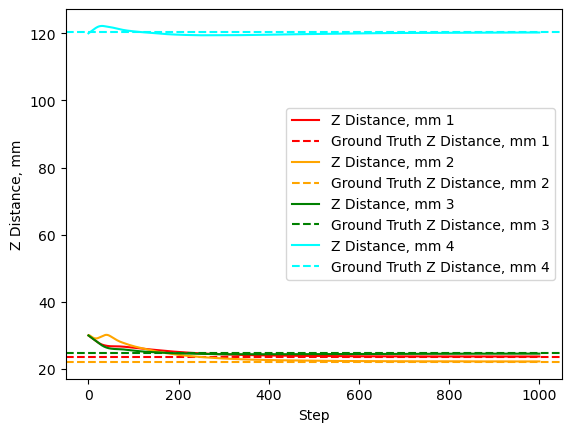

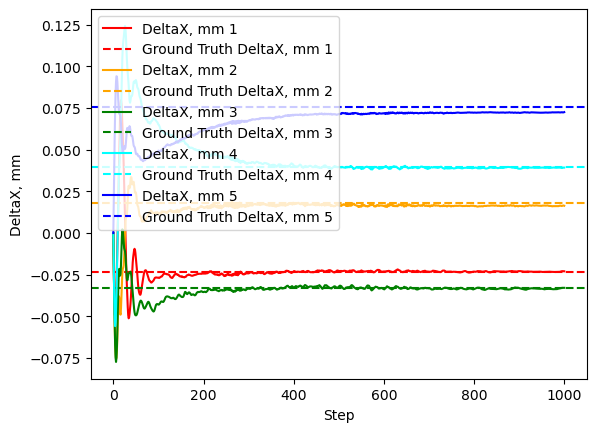

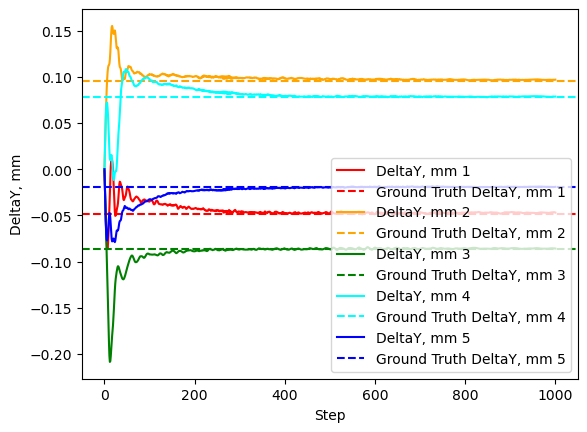

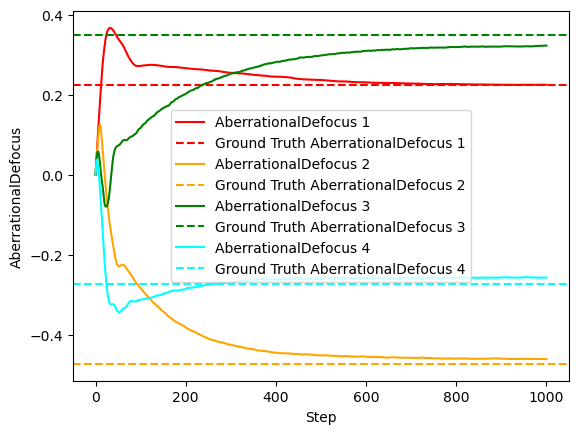

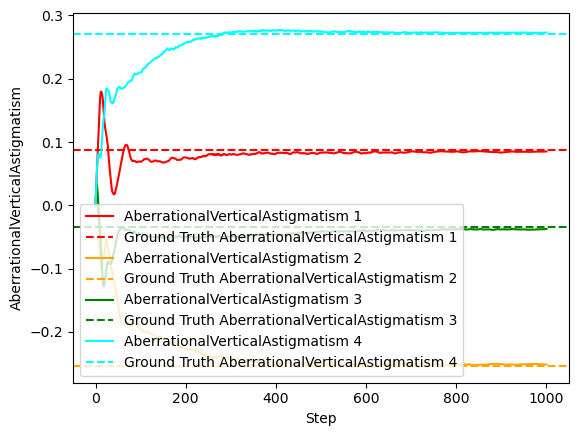

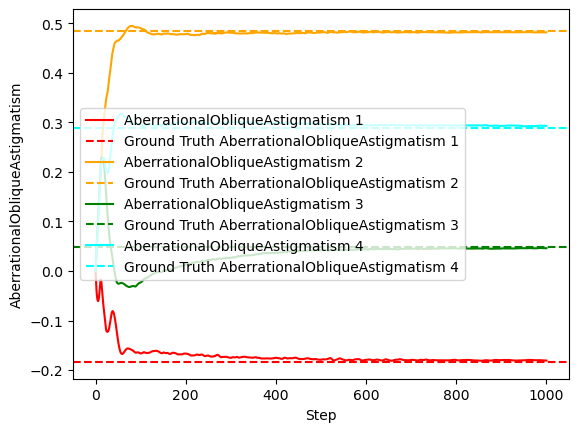

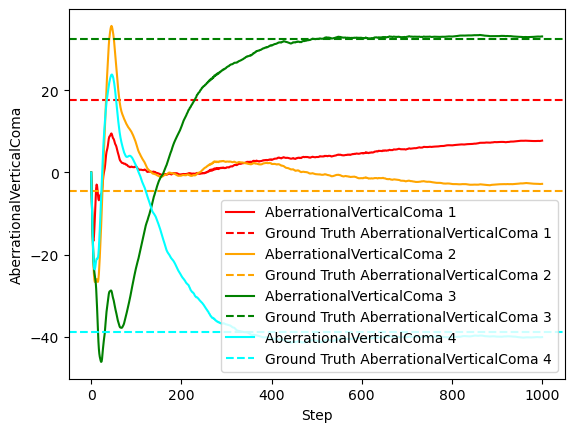

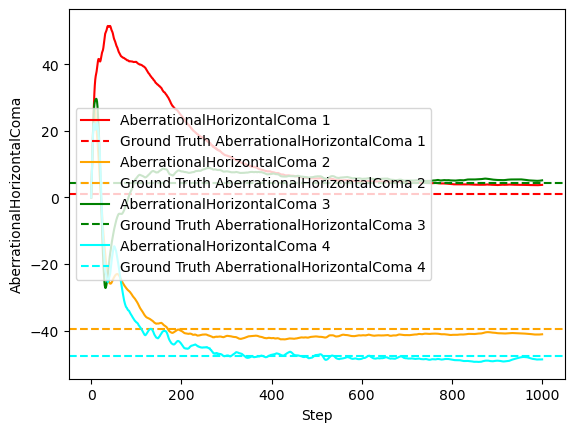

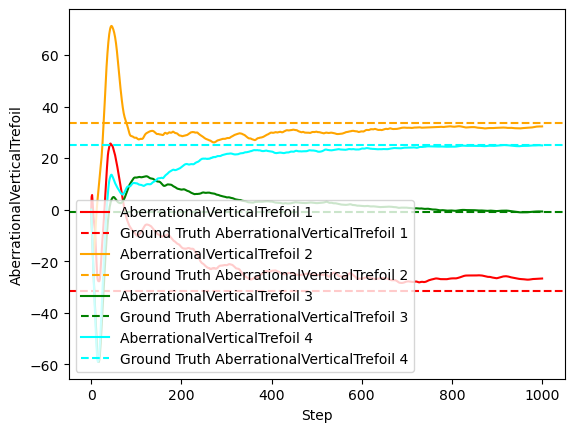

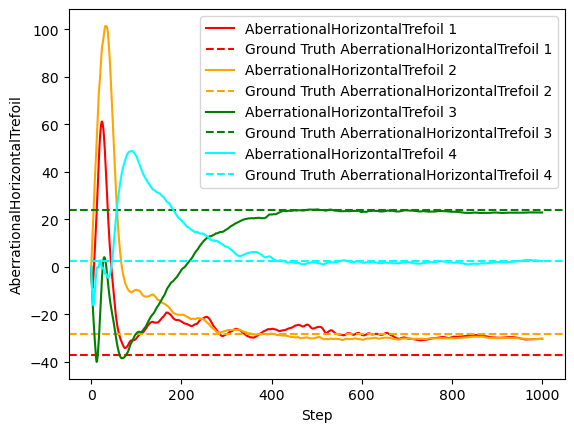

In [3]:
#Cell 3, convergence plots of all independent parameters
PlottingThings = [distancesStack*1000,DeltaXsStack*1000,DeltaYsStack*1000,AberrationalDefocusesStack,AberrationalVerticalAstigmatismsStack,AberrationalObliqueAstigmatismsStack,AberrationalVerticalComasStack,AberrationalHorizontalComasStack,AberrationalVerticalTrefoilsStack,AberrationalHorizontalTrefoilsStack]
Labels = ['Z Distance, mm','DeltaX, mm','DeltaY, mm','AberrationalDefocus','AberrationalVerticalAstigmatism','AberrationalObliqueAstigmatism','AberrationalVerticalComa','AberrationalHorizontalComa','AberrationalVerticalTrefoil','AberrationalHorizontalTrefoil']
ReferenceValues = [mplcGroundTruth.distances*1000,mplcGroundTruth.DeltaXs*1000,mplcGroundTruth.DeltaYs*1000,mplcGroundTruth.AberrationalDefocuses,mplcGroundTruth.AberrationalVerticalAstigmatisms,mplcGroundTruth.AberrationalObliqueAstigmatisms,mplcGroundTruth.AberrationalVerticalComas,mplcGroundTruth.AberrationalHorizontalComas,mplcGroundTruth.AberrationalVerticalTrefoils,mplcGroundTruth.AberrationalHorizontalTrefoils]

colours = ['red','orange','green','cyan','blue','violet','brown']#dimensions must be at least the number of phase masks
for i in range(len(PlottingThings)):
    fig, ax = plt.subplots()
    for j in range(len(PlottingThings[i][0])):
        ax.plot(range(Steps), PlottingThings[i][:,j],       label = f'{Labels[i]} {j+1}',              color=colours[j])
        ax.axhline(y=ReferenceValues[i][j], linestyle='--', label = f'Ground Truth {Labels[i]} {j+1}', color=colours[j])
    ax.set_xlabel('Step')
    ax.set_ylabel(f'{Labels[i]}')
    ax.legend()

In [4]:
#Cell 4, simulation-trained, Sigma-Annealed GS algorithm for perfectly-aligned 4-plane MPLC that transforms a gaussian beam into an image
matplotlib.use("Agg")
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from scipy.ndimage import zoom, gaussian_filter

# ── Parameters ──────────────────────────────────────────────────
N_ITER   = 300#training steps

# Graduated sigma annealing parameters
SIGMA_MAX = 5.0   # starting blur (pixels) — large sigma forces smooth masks early
SIGMA_MIN = 0.7   # ending blur (pixels)   — nonzero keeps masks smooth at convergence

x = (np.arange(Npx) - Npx/2) * PxWidth
X, Y = np.meshgrid(x, x)

Distances = np.array(DesiredDistances)#perfect setup
DXs = np.zeros(Nmasks+1)
DYs = np.zeros(Nmasks+1)

# ── Propagator ──────────────────────────────────────────────────
k = 2*np.pi/wavelength
k_x = np.arange(-Npx/2, Npx/2) * 2 * np.pi / (Npx * PxWidth)
k_y = np.arange(-Npx/2, Npx/2) * 2 * np.pi / (Npx * PxWidth)
kx, ky = np.meshgrid(k_x, k_y)
kz = np.sqrt(k**2 - kx**2 - ky**2 + 0j)

def prop(f, d, DiffX, DiffY):
    InitialAngularSpectrum = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(f)))
    H = np.exp(1j * (kz * d + kx * DiffX + ky * DiffY))
    NewAngularSpectrum = InitialAngularSpectrum * H
    Field_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(NewAngularSpectrum)))#field arriving at next plane (Before phase mask)
    return Field_out

def smooth_phase(phi, sigma):
    """Gaussian blur in phasor domain — handles 2pi wrapping correctly.
    Blurs cos(phi) and sin(phi) separately, then recovers angle via arctan2.
    This avoids discontinuity artefacts at the +pi/-pi wrap boundary."""
    if sigma < 1e-6:
        return phi
    sr = gaussian_filter(np.cos(phi), sigma=sigma)
    si = gaussian_filter(np.sin(phi), sigma=sigma)
    return np.arctan2(si, sr)

# ── Input Gaussian ───────────────────────────────────────────────
E_in = np.exp(-((X+DXs[0])**2 + (Y+DYs[0])**2) / w0**2).astype(complex)
E_in /= np.sqrt(np.sum(np.abs(E_in)**2))

# ── Load & process the Exeter Roundel image ─────────────────────
def load_target_image(path, n):
    """
    Convert RGBA image to target intensity:
      - Composite onto white background (remove transparency)
      - Convert to greyscale
      - Invert: dark pixels → high intensity, white → 0
      - Resize to n×n, normalise
    """
    img = Image.open(path).convert("RGBA")

    # Composite onto white background so transparent = white
    bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
    composite = Image.alpha_composite(bg, img).convert("RGB")

    # Greyscale brightness
    brightness = np.array(composite.convert("L"), dtype=float)   # 0=black, 255=white

    # Invert: intensity is proportional to darkness in logo
    intensity = 255.0 - brightness

    # Resize to N×N using zoom
    scale = n / brightness.shape[0]
    intensity = zoom(intensity, scale, order=3)
    intensity = np.clip(intensity, 0, None)

    # Normalise amplitude (not intensity) so total power = 1
    intensity /= intensity.max()
    return np.flip(intensity, axis=0)

def phase_roughness(phi):
    """RMS of wrapped nearest-neighbour phase differences."""
    def wrap(d): return (d + np.pi) % (2*np.pi) - np.pi
    dx = wrap(np.diff(phi, axis=1))
    dy = wrap(np.diff(phi, axis=0))
    return float(np.sqrt(np.mean(dx**2) + np.mean(dy**2)))

print("Loading target image...", flush=True)
Target = load_target_image("Exeter-Roundel.png", Npx)
Target /= np.sum(Target)
T_amp = np.sqrt(Target)

# ── Forward pass ─────────────────────────────────────────────────
def simulate(E, masks, Distances, DXs, DYs):
    E_bef = []
    cur = E.copy()
    for i in range(len(masks)):
        E_bef.append(cur.copy())
        cur = cur * np.exp(1j * masks[i])
        cur = prop(cur, Distances[i], DXs[i+1]-DXs[i], DYs[i+1]-DYs[i])
    return cur, E_bef

#Flat masks baseline
FlatMasks = np.zeros((Nmasks, Npx, Npx))
E_flat, _ = simulate(E_in, FlatMasks, Distances, DXs, DYs)
I_flat = np.abs(E_flat)**2

#Random masks baseline
RandomMasks = [np.random.uniform(0, 2*np.pi, (Npx, Npx)) for _ in range(Nmasks)]
E_rand, _ = simulate(E_in, RandomMasks, Distances, DXs, DYs)
I_rand = np.abs(E_rand)**2

#Training: MPLC Gerchberg-Saxton with graduated sigma annealing
TrainedMasks = [np.random.uniform(0, 2*np.pi, (Npx, Npx)) for _ in range(Nmasks)]
pearson_list = []
mse_list = []

print(f"Training for {N_ITER} iterations...", flush=True)
for it in range(N_ITER):
    # Cosine annealing schedule: sigma decays smoothly from SIGMA_MAX to SIGMA_MIN.
    # Early iterations use large sigma (coarse, smooth masks); later iterations
    # use small sigma (fine detail recovered while avoiding large phase jumps).
    frac  = it / max(N_ITER - 1, 1)
    sigma = SIGMA_MIN + 0.5 * (SIGMA_MAX - SIGMA_MIN) * (1 + np.cos(np.pi * frac))

    E_out, E_bef = simulate(E_in, TrainedMasks, Distances, DXs, DYs)
    I_out = np.abs(E_out)**2

    I_f = I_out.ravel()
    T_f = Target.ravel()
    pearson = float(np.corrcoef(I_f, T_f)[0, 1])
    mse = float(np.mean((np.sqrt(I_out) - T_amp)**2))
    pearson_list.append(pearson)
    mse_list.append(mse)
    if it % 20 == 0:
        print(f"  iter {it:3d}  Pearson={pearson}  MSE={mse}  sigma={sigma:.2f}", flush=True)

    # GS backward
    back = T_amp * np.exp(1j * np.angle(E_out))
    for i in range(Nmasks - 1, -1, -1):
        back = prop(back, -np.array(DesiredDistances)[i], -np.array(DXs)[i+1]+np.array(DXs)[i], -np.array(DYs)[i+1]+np.array(DYs)[i])
        TrainedMasks[i] = np.angle(back) - np.angle(E_bef[i])
        back = np.abs(back) * np.exp(1j * np.angle(E_bef[i]))

    # Smoothness step: apply phasor-domain Gaussian blur with annealed sigma.
    # sigma → 0 means the last iterations are near-pure GS (high fidelity),
    # while early iterations strongly enforce spatial smoothness.
    for i in range(Nmasks):
        TrainedMasks[i] = smooth_phase(TrainedMasks[i], sigma)

print(f"  Final     Pearson={pearson_list[-1]}  MSE={mse_list[-1]}", flush=True)

E_tr, _ = simulate(E_in, TrainedMasks, Distances, DXs, DYs)
I_tr = np.abs(E_tr)**2
r_tr = float(np.mean([phase_roughness(m) for m in TrainedMasks]))

# ── Plot ─────────────────────────────────────────────────────────
exeter_cmap = LinearSegmentedColormap.from_list(
    "exeter", ["#000000","#001A14","#003A2F","#006B56","#00A693","#7FFFD4","#FFFFFF"])

fig = plt.figure(figsize=(18, 14), facecolor="#080808")
fig.suptitle("No Misalignments 4-Plane MPLC - Trained Phase Masks",
             fontsize=16, color="white", fontweight="bold", y=0.977)

ext = np.array([-Npx/2, Npx/2, -Npx/2, Npx/2]) * PxWidth * 1e3
AX = dict(facecolor="#111111")
TK = dict(color="white", fontsize=11, fontweight="bold", pad=7)
LB = dict(color="#999999", fontsize=9)

def add_cbar(ax, im, ticks=None):
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors="white", labelsize=7)
    if ticks: 
        cb.set_ticks(ticks[0])
        cb.set_ticklabels(ticks[1])
    return cb

# Row 1
ax = fig.add_subplot(3, 4, 1, **AX)
im = ax.imshow(np.abs(E_in)**2, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest")
ax.set_title("Input Gaussian  (w_0=300µm)", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 2, **AX)
im = ax.imshow(Target, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest")
ax.set_title("Target Intensity  (from PNG)", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 3, **AX)
ax.semilogy(mse_list, color="#00A693", lw=1.8)
ax.set_title("Training MSE  (amplitude)", **TK)
ax.set_xlabel("Iteration", **LB)
ax.set_ylabel("MSE", **LB)
ax.tick_params(colors="#999999", labelsize=8)
ax.spines[:].set_color("#333333")
ax.grid(True, color="#1C1C1C", ls="--")

ax = fig.add_subplot(3, 4, 4, **AX)
ax.plot(pearson_list, color="#FFB347", lw=1.8)
ax.axhline(1.0, color="#555555", ls="--", lw=1)
ax.set_title("Pearson Correlation  Output vs Target", **TK)
ax.set_xlabel("Iteration", **LB)
ax.set_ylabel("r", **LB)
ax.tick_params(colors="#999999", labelsize=8)
ax.spines[:].set_color("#333333")
ax.grid(True, color="#1C1C1C", ls="--")

# Row 2 — trained phase masks
for i in range(Nmasks):
    ax = fig.add_subplot(3, 4, 5+i, **AX)
    im = ax.imshow(TrainedMasks[i] % (2*np.pi), extent=ext, cmap="twilight",
                   origin="lower", interpolation="nearest",
                   vmin=0, vmax=2*np.pi)
    ax.set_title(f"Phase Mask {i+1}  (trained)", **TK)
    ax.set_xlabel("x (mm)", **LB)
    ax.set_ylabel("y (mm)", **LB)
    add_cbar(ax, im, ticks=([0, np.pi, 2*np.pi], ["0", "π", "2π"]))

# Row 3 — output comparison

ax = fig.add_subplot(3, 4, 9, **AX)
im = ax.imshow(I_rand, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest", vmin=0, vmax=I_rand.max())
ax.set_title("Output - RANDOM UNTRAINED", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 10, **AX)
im = ax.imshow(I_flat, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest", vmin=0, vmax=I_flat.max())
ax.set_title("Output - FLAT UNTRAINED", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 11, **AX)
im = ax.imshow(I_tr, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest", vmin=0, vmax=I_tr.max())
ax.set_title("Output - TRAINED", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

# Metrics panel
ax = fig.add_subplot(3, 4, 12, **AX)
ax.axis("off")
p_flat = float(np.corrcoef(I_flat.ravel(),   Target.ravel())[0, 1])
p_rand = float(np.corrcoef(I_rand.ravel(), Target.ravel())[0, 1])
p_tr  = float(np.corrcoef(I_tr.ravel(),      Target.ravel())[0, 1])
eff_flat = float(np.sum(I_flat * Target) / np.sum(Target**2))
eff_rand = float(np.sum(I_rand * Target) / np.sum(Target**2))
eff_tr  = float(np.sum(I_tr      * Target) / np.sum(Target**2))
txt = (
    "── Performance ──\n\n"
    f" Pearson (trained):   {p_tr:.6f}\n"
    f" Roughness (trained): {r_tr:.6f} rad\n"
    f" Pearson (flat):      {p_flat:.6f}\n"
    f" Pearson (random):    {p_rand:.6f}\n\n"
    f" Weighted efficiency\n"
    f"   Trained: {eff_tr*100:.1f} %\n"
    f"   Flat:    {eff_flat*100:.1f} %\n"
    f"   Random:  {eff_rand*100:.1f} %\n\n"
    "── MPLC Config ──\n\n"
    f" Planes:      {Nmasks}\n"
    f" Grid:        {Npx}x{Npx}\n"
    f" Pixel Width: {PxWidth*1e6:.1f} µm\n"
    f" Wavelength:  {wavelength*1e9:.0f} nm\n"
    f" Distances:   30/30/30/150 mm\n"
    f" w_0:         {w0*1e6:.0f} µm\n"
    f" Iterations:  {N_ITER}\n"
    f" Algorithm:   GS + annealed σ ({SIGMA_MAX}→{SIGMA_MIN})"
)
ax.text(0.05, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
        fontsize=9.5, fontfamily="monospace", color="#00C8A8",
        bbox=dict(boxstyle="round,pad=0.6", fc="#091A16", ec="#00A693", alpha=0.95))

for a in fig.get_axes():
    for sp in a.spines.values(): sp.set_color("#333333")
    a.tick_params(colors="#888888", labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.967])
out = "mplc_image_output.png"
plt.savefig(out, dpi=155, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print(f"\nSaved -> {out}\nDone.")

Loading target image...
Training for 300 iterations...
  iter   0  Pearson=0.0006541769086788127  MSE=1.813015074464573e-05  sigma=5.00
  iter  20  Pearson=0.3639145654960599  MSE=1.206300185673732e-05  sigma=4.95
  iter  40  Pearson=0.5813529764519596  MSE=7.1574402120218535e-06  sigma=4.81
  iter  60  Pearson=0.6590885416663224  MSE=6.097616914377126e-06  sigma=4.59
  iter  80  Pearson=0.7129512783249021  MSE=5.285311059779733e-06  sigma=4.28
  iter 100  Pearson=0.7412149184761009  MSE=4.866096157416913e-06  sigma=3.92
  iter 120  Pearson=0.7699190279207646  MSE=4.428902404009212e-06  sigma=3.51
  iter 140  Pearson=0.7967040048686002  MSE=3.996264598136773e-06  sigma=3.06
  iter 160  Pearson=0.8251344467044858  MSE=3.498872040203783e-06  sigma=2.61
  iter 180  Pearson=0.8562969617824294  MSE=2.8913058960179863e-06  sigma=2.17
  iter 200  Pearson=0.8828857973340348  MSE=2.3227132666353313e-06  sigma=1.76
  iter 220  Pearson=0.9130018904334432  MSE=1.6933106878040959e-06  sigma=1.40
  

In [5]:
#Cell 5, Performance test of misaligned vs optimised vs perfect MPLC with phase masks designed to produce an image

#Completely misaligned
MisalignedMasks = TrainedMasks + mplcGroundTruth.aberrations.detach().cpu().numpy()[:,0,:,:]
MisalignedDistances = mplcGroundTruth.distances.detach().cpu().numpy()
MisalignedDeltaXs = mplcGroundTruth.DeltaXs.detach().cpu().numpy()
MisalignedDeltaYs = mplcGroundTruth.DeltaYs.detach().cpu().numpy()

#Computer-optimised model
OptimisedMasks = TrainedMasks + mplcGroundTruth.aberrations.detach().cpu().numpy()[:,0,:,:] - mplcGuess.aberrations.detach().cpu().numpy()[:,0,:,:]
OptimisedDistances = np.array(DesiredDistances) + mplcGroundTruth.distances.detach().cpu().numpy() - mplcGuess.distances.detach().cpu().numpy()
OptimisedDeltaXs = (mplcGroundTruth.DeltaXs.detach().cpu().numpy() - mplcGuess.DeltaXs.detach().cpu().numpy())
OptimisedDeltaYs = (mplcGroundTruth.DeltaYs.detach().cpu().numpy() - mplcGuess.DeltaYs.detach().cpu().numpy())

#Simulate
E_Misaligned, _ = simulate(E_in, MisalignedMasks, MisalignedDistances, MisalignedDeltaXs, MisalignedDeltaYs)
E_Optimised, _  = simulate(E_in, OptimisedMasks,  OptimisedDistances,  OptimisedDeltaXs,  OptimisedDeltaYs)
E_Misaligned, _ = simulate(E_in, MisalignedMasks, MisalignedDistances, np.zeros(Nmasks+1), np.zeros(Nmasks+1))
E_Optimised, _  = simulate(E_in, OptimisedMasks,  OptimisedDistances,  np.zeros(Nmasks+1), np.zeros(Nmasks+1))


I_Misaligned = np.abs(E_Misaligned)**2
I_Optimised = np.abs(E_Optimised)**2

#Plot
fig = plt.figure(figsize=(18, 14), facecolor="#080808")
fig.suptitle("4-Plane MPLC  -  Aligned vs Misaligned Performance",
             fontsize=16, color="white", fontweight="bold", y=0.977)

# Row 1
ax = fig.add_subplot(3, 4, 1, **AX)
im = ax.imshow(np.abs(E_in)**2, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest")
ax.set_title("Input Gaussian  (w\u2080=300 \u00b5m)", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 2, **AX)
im = ax.imshow(Target, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest")
ax.set_title("Target Intensity  (from PNG)", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 3, **AX)
ax.axis("off")
p_perf = float(np.corrcoef(I_tr.ravel(), Target.ravel())[0, 1])
p_mis = float(np.corrcoef(I_Misaligned.ravel(), Target.ravel())[0, 1])
p_optim  = float(np.corrcoef(I_Optimised.ravel(), Target.ravel())[0, 1])
eff_perf = float(np.sum(I_tr * Target) / np.sum(Target**2))
eff_mis = float(np.sum(I_Misaligned * Target) / np.sum(Target**2))
eff_optim  = float(np.sum(I_Optimised * Target) / np.sum(Target**2))
txt = (
    "── Performance ──\n\n"
    f" Pearson (no misalignments): {p_perf:.6f}\n"
    f" Pearson (misaligned):       {p_mis:.6f}\n"
    f" Pearson (optimised):        {p_optim:.6f}\n\n"
    f" Weighted efficiency\n"
    f"   No misalignments: {eff_perf*100:.1f} %\n"
    f"   Misaligned:       {eff_mis*100:.1f} %\n"
    f"   Optimised:        {eff_optim*100:.1f} %\n\n"
    "── MPLC Config ──\n\n"
    f" Planes:      {Nmasks}\n"
    f" Grid:        {Npx}x{Npx}\n"
    f" Pixel Width: {PxWidth*1e6:.1f} µm\n"
    f" Wavelength:  {wavelength*1e9:.0f} nm\n"
    f" Distances:   30/30/30/150 mm\n"
    f" w_0:         {w0*1e6:.0f} µm\n"
    f" Iterations:  {N_ITER}\n"
    f" Algorithm:   GS + annealed σ ({SIGMA_MAX}→{SIGMA_MIN})"
)
ax.text(0.05, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
        fontsize=9.5, fontfamily="monospace", color="#00C8A8",
        bbox=dict(boxstyle="round,pad=0.6", fc="#091A16", ec="#00A693", alpha=0.95))

#Row 2
ax = fig.add_subplot(3, 4, 5, **AX)
im = ax.imshow(I_tr, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest", vmin=0, vmax=I_tr.max())
ax.set_title("Output - TRAINED, no misalignments", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 6, **AX)
im = ax.imshow(I_Misaligned, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest", vmin=0, vmax=I_Misaligned.max())
ax.set_title("Output - TRAINED, misaligned", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)

ax = fig.add_subplot(3, 4, 7, **AX)
im = ax.imshow(I_Optimised, extent=ext, cmap=exeter_cmap,
               origin="lower", interpolation="nearest", vmin=0, vmax=I_Optimised.max())
ax.set_title("Output - TRAINED, optimised", **TK)
ax.set_xlabel("x (mm)", **LB)
ax.set_ylabel("y (mm)", **LB)
add_cbar(ax, im)


for a in fig.get_axes():
    for sp in a.spines.values(): sp.set_color("#333333")
    a.tick_params(colors="#888888", labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.967])
out = "ValidationRun.png"
plt.savefig(out, dpi=155, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print(f"\nSaved -> {out}\nDone.")


Saved -> ValidationRun.png
Done.


In [6]:
#Cell 6, comparison of smoothing algorithms used to make results less sensitive to misalignments
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from scipy.ndimage import zoom, gaussian_filter
 
# ── Parameters ──────────────────────────────────────────────────
N        = 200
DX       = 10.8e-6
LAM      = 633e-9
DISTS    = [30e-3, 30e-3, 30e-3, 120e-3]
W0       = 300e-6
N_ITER   = 300
SEED     = 42

# Algorithm 2: Annealing
SIGMA_MAX = 5.0   # starting blur (pixels)
SIGMA_MIN = 0.7   # ending blur — nonzero keeps masks smooth at end
 
# Algorithm 3: Tikhonov proximal
TIK_LAMBDA = 0.5  # L2 phase-gradient penalty strength
 
rng = np.random.default_rng(SEED)
x = (np.arange(N) - N/2) * DX
X, Y = np.meshgrid(x, x)
 
# Propagator
fx = np.fft.fftfreq(N, d=DX)
FX, FY = np.meshgrid(fx, fx)
KZ = np.sqrt(np.maximum((1/LAM)**2 - FX**2 - FY**2, 0.0))
def propagate(f, d):
    return np.fft.ifft2(np.fft.fft2(f) * np.exp(1j * 2*np.pi * KZ * d))
 
# Input Gaussian
E_in = np.exp(-(X**2 + Y**2) / W0**2).astype(complex)
E_in /= np.sqrt(np.sum(np.abs(E_in)**2))


def forward(E, masks):
    E_bef = []; cur = E.copy()
    for m, d in zip(masks, DISTS):
        E_bef.append(cur.copy())
        cur = cur * np.exp(1j * m)
        cur = propagate(cur, d)
    return cur, E_bef
 
def gs_step(E_out, E_bef, masks):
    """One GS backward pass. Returns updated masks."""
    back = T_amp * np.exp(1j * np.angle(E_out))
    new_masks = list(masks)
    for i in range(Nmasks - 1, -1, -1):
        back = propagate(back, -DISTS[i])
        new_masks[i] = np.angle(back) - np.angle(E_bef[i])
        back = np.abs(back) * np.exp(1j * np.angle(E_bef[i]))
    return new_masks
 
def smooth_phase(phi, sigma):
    """Gaussian blur in phasor domain — handles 2pi wrapping correctly."""
    if sigma < 1e-6:
        return phi
    sr = gaussian_filter(np.cos(phi), sigma=sigma)
    si = gaussian_filter(np.sin(phi), sigma=sigma)
    return np.arctan2(si, sr)
    
kx = np.fft.fftfreq(N)
KX, KY = np.meshgrid(kx, kx)
LAP_EIG = 4 - 2*np.cos(2*np.pi*KX) - 2*np.cos(2*np.pi*KY)   # exact discrete Laplacian
 
def tikhonov_prox(phi, lam):
    """
    Proximal operator of  J = lam * sum |phi_{i+1,j} - phi_{i,j}|^2 + |phi_{i,j+1} - phi_{i,j}|^2
    Applied in phasor domain to handle phase wrapping.
    Equivalent to: blur the phasor with transfer function 1 / (1 + lam * |k_discrete|^2)
    """
    phasor = np.exp(1j * phi)
    F = np.fft.fft2(phasor)
    F_smooth = F / (1.0 + lam * LAP_EIG)
    return np.angle(np.fft.ifft2(F_smooth))
 
def phase_roughness(phi):
    """RMS of wrapped nearest-neighbour phase differences."""
    def wrap(d): return (d + np.pi) % (2*np.pi) - np.pi
    dx = wrap(np.diff(phi, axis=1))
    dy = wrap(np.diff(phi, axis=0))
    return float(np.sqrt(np.mean(dx**2) + np.mean(dy**2)))
 
def get_metrics(masks):
    E_out, _ = forward(E_in, masks)
    I_out = np.abs(E_out)**2
    p = float(np.corrcoef(I_out.ravel(), Target.ravel())[0, 1])
    r = float(np.mean([phase_roughness(m) for m in masks]))
    return p, r, I_out
 
# ── Shared initial masks ─────────────────────────────────────────
init_masks = [rng.uniform(0, 2*np.pi, (N, N))*0 for _ in range(Nmasks)]
 

# ALGORITHM 1 — Baseline GS - no regularisation (Pearson→1, roughness = high)

print("\n[1] Baseline GS...", flush=True)
masks_gs = [m.copy() for m in init_masks]
gs_pearson, gs_rough = [], []
 
for it in range(N_ITER):
    E_out, E_bef = forward(E_in, masks_gs)
    p, r, _ = get_metrics(masks_gs)
    gs_pearson.append(p); gs_rough.append(r)
    if it % 100 == 0:
        print(f"  {it:3d}  P={p:.5f}  R={r:.4f}", flush=True)
    masks_gs = gs_step(E_out, E_bef, masks_gs)
 
_, _, I_gs = get_metrics(masks_gs)
print(f"  Done  P={gs_pearson[-1]:.5f}  R={gs_rough[-1]:.4f}", flush=True)
 

# ALGORITHM 2 — Annealed-sigma GS — cosine-annealed Gaussian blur
# Sigma_max→sigma_min Phasor-domain blur avoids 2pi wrap artefacts.
# Trades a little fidelity for very smooth masks.
# Cosine schedule: sigma(t) = sigma_min + 0.5*(sigma_max-sigma_min)*(1+cos(pi*t))

print("\n[2] Annealed-sigma GS...", flush=True)
masks_ann = [m.copy() for m in init_masks]
ann_pearson, ann_rough, ann_sigma = [], [], []
 
for it in range(N_ITER):
    frac  = it / max(N_ITER - 1, 1)
    sigma = SIGMA_MIN + 0.5*(SIGMA_MAX - SIGMA_MIN)*(1 + np.cos(np.pi*frac))
    ann_sigma.append(sigma)
 
    E_out, E_bef = forward(E_in, masks_ann)
    p, r, _ = get_metrics(masks_ann)
    ann_pearson.append(p); ann_rough.append(r)
    if it % 100 == 0:
        print(f"  {it:3d}  P={p:.5f}  R={r:.4f}  sigma={sigma:.2f}", flush=True)
 
    masks_ann = gs_step(E_out, E_bef, masks_ann)
    # Smooth in phasor domain — sigma decays toward sigma_min each iter
    for i in range(Nmasks):
        masks_ann[i] = smooth_phase(masks_ann[i], sigma)
 
_, _, I_ann = get_metrics(masks_ann)
print(f"  Done  P={ann_pearson[-1]:.5f}  R={ann_rough[-1]:.4f}", flush=True)

# ALGORITHM 3 — GS + Tikhonov proximal (Fourier)
#
# After each GS step, apply the proximal operator of
#   J_smooth = lambda * ||nabla phi||_F^2
# in Fourier space via the exact discrete Laplacian.
# This is equivalent to solving a Tikhonov regularisation problem
# analytically at each iteration:
#   phi_reg[k] = phi_GS[k] / (1 + lambda * eigenvalue_k)
# Applied to the phasor exp(j*phi) to respect phase wrapping.
# Analytically optimal L2 phase-gradient penalty.
# Converges to a stable fidelity/smoothness trade-off.

print("\n[3] GS + Tikhonov proximal...", flush=True)
masks_tik = [m.copy() for m in init_masks]
tik_pearson, tik_rough = [], []
 
for it in range(N_ITER):
    E_out, E_bef = forward(E_in, masks_tik)
    p, r, _ = get_metrics(masks_tik)
    tik_pearson.append(p); tik_rough.append(r)
    if it % 100 == 0:
        print(f"  {it:3d}  P={p:.5f}  R={r:.4f}", flush=True)
 
    masks_tik = gs_step(E_out, E_bef, masks_tik)
    for i in range(Nmasks):
        masks_tik[i] = tikhonov_prox(masks_tik[i], TIK_LAMBDA)
 
_, _, I_tik = get_metrics(masks_tik)
print(f"  Done  P={tik_pearson[-1]:.5f}  R={tik_rough[-1]:.4f}", flush=True)
 
# Plotting
exeter_cmap = LinearSegmentedColormap.from_list(
    "exeter", ["#000000","#001A14","#003A2F","#006B56","#00A693","#7FFFD4","#FFFFFF"])
 
fig = plt.figure(figsize=(22, 18), facecolor="#080808")
fig.suptitle(
    "4-Plane MPLC  \u2014  Phase Smoothness Regularisation:  "
    "Baseline GS  |  Annealed \u03c3  |  Tikhonov Proximal",
    fontsize=13.5, color="white", fontweight="bold", y=0.979)
 
ext = np.array([-N/2, N/2, -N/2, N/2]) * DX * 1e3
AX = dict(facecolor="#111111")
TK = dict(color="white", fontsize=9.5, fontweight="bold", pad=5)
LB = dict(color="#999999", fontsize=8.5)
C1, C2, C3 = "#FF6B6B", "#FFB347", "#00A693"
 
def add_cbar(ax, im, ticks=None):
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors="white", labelsize=6)
    if ticks:
        cb.set_ticks(ticks[0]); cb.set_ticklabels(ticks[1])
    return cb
 
# ── Row 1: target + convergence curves ───────────────────────────
ax = fig.add_subplot(5, 5, 1, **AX)
im = ax.imshow(Target, extent=ext, cmap=exeter_cmap, origin="lower", interpolation="nearest")
ax.set_title("Target  (Exeter PNG)", **TK)
ax.set_xlabel("x (mm)", **LB); ax.set_ylabel("y (mm)", **LB); add_cbar(ax, im)
 
ax = fig.add_subplot(5, 5, 2, **AX)
ax.plot(gs_pearson,  color=C1, lw=1.7, label="Baseline GS")
ax.plot(ann_pearson, color=C2, lw=1.7, label=f"Annealed \u03c3 ({SIGMA_MAX}\u2192{SIGMA_MIN})")
ax.plot(tik_pearson, color=C3, lw=1.7, label=f"Tikhonov \u03bb={TIK_LAMBDA}")
ax.axhline(1.0, color="#444", ls="--", lw=1)
ax.set_title("Pearson Correlation vs Iteration", **TK)
ax.set_xlabel("Iteration", **LB); ax.set_ylabel("r", **LB)
ax.legend(fontsize=7.5, facecolor="#111", edgecolor="#444", labelcolor="white", loc="lower right")
ax.tick_params(colors="#999"); ax.spines[:].set_color("#333"); ax.grid(True, color="#1C1C1C", ls="--")
 
ax = fig.add_subplot(5, 5, 3, **AX)
ax.plot(gs_rough,  color=C1, lw=1.7, label="Baseline GS")
ax.plot(ann_rough, color=C2, lw=1.7, label=f"Annealed \u03c3")
ax.plot(tik_rough, color=C3, lw=1.7, label=f"Tikhonov")
ax.set_title("Phase Roughness  (RMS \u0394\u03c6 per iter)", **TK)
ax.set_xlabel("Iteration", **LB); ax.set_ylabel("RMS \u0394\u03c6  (rad)", **LB)
ax.legend(fontsize=7.5, facecolor="#111", edgecolor="#444", labelcolor="white")
ax.tick_params(colors="#999"); ax.spines[:].set_color("#333"); ax.grid(True, color="#1C1C1C", ls="--")
 
ax = fig.add_subplot(5, 5, 4, **AX)
ax.plot(ann_sigma, color=C2, lw=1.8)
ax.set_title(f"Annealing Schedule  (\u03c3: {SIGMA_MAX}\u2192{SIGMA_MIN})", **TK)
ax.set_xlabel("Iteration", **LB); ax.set_ylabel("\u03c3  (pixels)", **LB)
ax.tick_params(colors="#999"); ax.spines[:].set_color("#333"); ax.grid(True, color="#1C1C1C", ls="--")
 
ax = fig.add_subplot(5, 5, 5, **AX)
def ndiffs(ms):
    out = []
    for m in ms:
        def w(d): return (d+np.pi)%(2*np.pi)-np.pi
        out += [w(np.diff(m, axis=1)).ravel(), w(np.diff(m, axis=0)).ravel()]
    return np.concatenate(out)
bins = np.linspace(-np.pi, np.pi, 80)
ax.hist(ndiffs(masks_gs),  bins=bins, color=C1, alpha=0.55, density=True, label="Baseline GS")
ax.hist(ndiffs(masks_ann), bins=bins, color=C2, alpha=0.55, density=True, label="Annealed \u03c3")
ax.hist(ndiffs(masks_tik), bins=bins, color=C3, alpha=0.55, density=True, label="Tikhonov")
ax.set_title("Neighbour \u0394\u03c6 Distribution  (final)", **TK)
ax.set_xlabel("\u0394\u03c6  (rad)", **LB); ax.set_ylabel("Density", **LB)
ax.legend(fontsize=7.5, facecolor="#111", edgecolor="#444", labelcolor="white")
ax.tick_params(colors="#999"); ax.spines[:].set_color("#333"); ax.grid(True, color="#1C1C1C", ls="--")
 
# ── Rows 2–4: phase masks (one row per algorithm) ─────────────────
vmax_phi = 2*np.pi
for row_idx, (alg_masks, alg_label, I_alg, col_c) in enumerate([
        (masks_gs,  "Baseline GS",           I_gs,  C1),
        (masks_ann, f"Annealed \u03c3",       I_ann, C2),
        (masks_tik, "Tikhonov Proximal",      I_tik, C3)]):
    for i in range(Nmasks):
        ax = fig.add_subplot(5, 5, 6 + row_idx*5 + i, **AX)
        im = ax.imshow(alg_masks[i] % (2*np.pi), extent=ext, cmap="twilight",
                       origin="lower", interpolation="nearest",
                       vmin=0, vmax=vmax_phi)
        ax.set_title(f"{alg_label}  \u2014  Mask {i+1}", **TK)
        ax.set_xlabel("x (mm)", **LB); ax.set_ylabel("y (mm)", **LB)
        add_cbar(ax, im, ticks=([0, np.pi, 2*np.pi], ["0", "\u03c0", "2\u03c0"]))
    # 5th column: output intensity
    ax = fig.add_subplot(5, 5, 6 + row_idx*5 + 4, **AX)
    im = ax.imshow(I_alg, extent=ext, cmap=exeter_cmap, origin="lower",
                   interpolation="nearest", vmin=0, vmax=I_alg.max())
    p_f = [gs_pearson[-1], ann_pearson[-1], tik_pearson[-1]][row_idx]
    r_f = [gs_rough[-1],   ann_rough[-1],   tik_rough[-1]][row_idx]
    ax.set_title(f"{alg_label}\nr={p_f:.4f}  rms\u0394\u03c6={r_f:.3f} rad", color=col_c,
                 fontsize=9.5, fontweight="bold", pad=5)
    ax.set_xlabel("x (mm)", **LB); ax.set_ylabel("y (mm)", **LB); add_cbar(ax, im)
 
# ── Row 5: side-by-side output + metrics ─────────────────────────
vmax_all = max(I_gs.max(), I_ann.max(), I_tik.max())
for col, (I_alg, label, col_c) in enumerate([
        (I_gs,  "Baseline GS",      C1),
        (I_ann, "Annealed \u03c3",  C2),
        (I_tik, "Tikhonov Proximal",C3)]):
    ax = fig.add_subplot(5, 5, 21+col, **AX)
    im = ax.imshow(I_alg, extent=ext, cmap=exeter_cmap, origin="lower",
                   interpolation="nearest", vmin=0, vmax=vmax_all)
    ax.set_title(label, color=col_c, fontsize=10, fontweight="bold", pad=5)
    ax.set_xlabel("x (mm)", **LB); ax.set_ylabel("y (mm)", **LB); add_cbar(ax, im)
 
ax = fig.add_subplot(5, 5, 24, **AX)
diff = I_tik - I_gs; vlim = np.abs(diff).max()
im = ax.imshow(diff, extent=ext, cmap="RdBu_r", origin="lower",
               interpolation="nearest", vmin=-vlim, vmax=vlim)
ax.set_title("Tikhonov \u2212 Baseline GS", **TK)
ax.set_xlabel("x (mm)", **LB); ax.set_ylabel("y (mm)", **LB); add_cbar(ax, im)
 
# Summary metrics panel
ax = fig.add_subplot(5, 5, 25, **AX); ax.axis("off")
gs_p, gs_r   = gs_pearson[-1],  gs_rough[-1]
ann_p, ann_r = ann_pearson[-1], ann_rough[-1]
tik_p, tik_r = tik_pearson[-1], tik_rough[-1]
 
def bar(val, best, width=8, hi=True):
    frac = (val/best if best>0 else 0) if hi else (best/val if val>0 else 0)
    n = int(round(frac*width))
    return "\u2588"*n + "\u2591"*(width-n)

bp = max(gs_p, ann_p, tik_p)
br = min(gs_r, ann_r, tik_r)

txt = (
    "\u2500\u2500 Summary \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n\n"
    " Pearson  (\u25b2 better)\n"
    f"  GS  {bar(gs_p,bp)}  {gs_p:.4f}\n"
    f"  Ann {bar(ann_p,bp)}  {ann_p:.4f}\n"
    f"  Tik {bar(tik_p,bp)}  {tik_p:.4f}\n\n"
    " Roughness  (\u25bc better)\n"
    f"  GS  {bar(gs_r,br,hi=False)}  {gs_r:.3f} rad\n"
    f"  Ann {bar(ann_r,br,hi=False)}  {ann_r:.3f} rad\n"
    f"  Tik {bar(tik_r,br,hi=False)}  {tik_r:.3f} rad\n\n"
    " Roughness reduction\n"
    f"  Ann: {(1-ann_r/gs_r)*100:.0f}% vs GS\n"
    f"  Tik: {(1-tik_r/gs_r)*100:.0f}% vs GS\n\n"
    "\u2500\u2500 Config \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n"
    f"  N={N}  \u0394x={DX*1e6:.1f}\u00b5m  {N_ITER} iters\n"
    f"  Ann: \u03c3 {SIGMA_MAX}\u2192{SIGMA_MIN} (cosine)\n"
    f"  Tik: \u03bb={TIK_LAMBDA} (Fourier prox)"
)

ax.text(0.04, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
        fontsize=9, fontfamily="monospace", color="#00C8A8",
        bbox=dict(boxstyle="round,pad=0.6", fc="#091A16", ec="#00A693", alpha=0.95))
 
for a in fig.get_axes():
    for sp in a.spines.values(): sp.set_color("#333")
    a.tick_params(colors="#888", labelsize=7)
 
plt.tight_layout(rect=[0, 0, 1, 0.974])
out = "mplc_algorithm_comparison.png"
plt.savefig(out, dpi=140, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print(f"\nSaved -> {out}\nDone.")


[1] Baseline GS...
    0  P=0.17295  R=0.0000
  100  P=1.00000  R=2.1382
  200  P=1.00000  R=2.1382
  Done  P=1.00000  R=2.1382

[2] Annealed-sigma GS...
    0  P=0.17295  R=0.0000  sigma=5.00
  100  P=0.76176  R=0.2831  sigma=3.92
  200  P=0.88818  R=0.5472  sigma=1.76
  Done  P=0.97849  R=1.0840

[3] GS + Tikhonov proximal...
    0  P=0.17295  R=0.0000
  100  P=0.97007  R=1.3330
  200  P=0.97153  R=1.2899
  Done  P=0.97254  R=1.2224

Saved -> mplc_algorithm_comparison.png
Done.
